Alice bits:  [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
Alice bases: [1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0]
Bob bases:   [1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0]
Kept idx:    [0, 2, 5, 6, 8, 10, 12, 13, 14, 15]

Alice sifted key: [0, 1, 0, 0, 1, 0, 0, 0, 0, 0]
Bob sifted key:   [0, 1, 0, 0, 1, 0, 0, 0, 0, 0]
Keys match?:      True
Retention rate:   0.625
{'step_1': 'passed'}

BB84 Basis Comparison Table:


,Index,Alice Bit,Alice Basis,Bob Basis,Basis Match
0,0,0,1,1,True
1,1,0,0,1,False
2,2,1,1,1,True
3,3,0,1,0,False
4,4,0,0,1,False
5,5,0,0,0,True
6,6,0,1,1,True
7,7,0,1,0,False
8,8,1,1,1,True
9,9,0,0,1,False


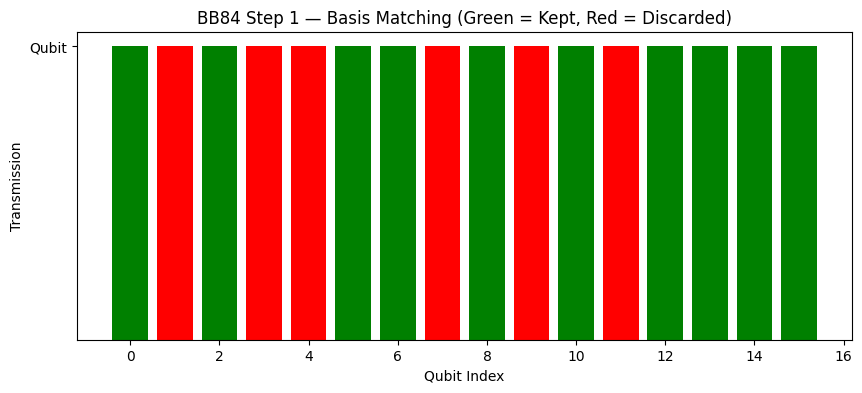

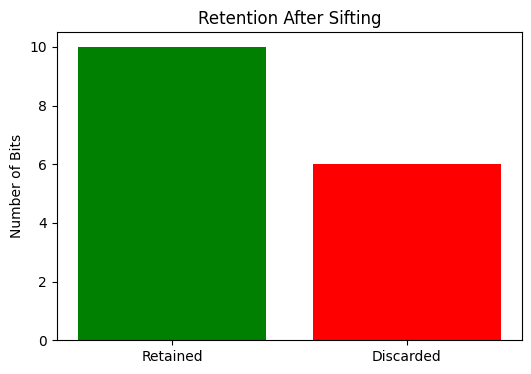

Retention Rate: 0.625


In [2]:
import random
from typing import List, Tuple

import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


# =========================================================
# Step 1: Parameters
# =========================================================
N = 16        # number of qubits
SEED = 42     # reproducibility
SHOTS = 1     # BB84 is conceptually one transmission per qubit


# =========================================================
# Step 2: Generate Alice bits/bases and Bob bases
# =========================================================
def gen_bits_bases(n: int, seed: int) -> Tuple[List[int], List[int], List[int]]:
    """
    Generate random data for BB84.
    Returns:
        alice_bits: 0/1 bits
        alice_bases: 0(Z) or 1(X)
        bob_bases: 0(Z) or 1(X)
    """
    rng = random.Random(seed)
    alice_bits = [rng.randint(0, 1) for _ in range(n)]
    alice_bases = [rng.randint(0, 1) for _ in range(n)]
    bob_bases = [rng.randint(0, 1) for _ in range(n)]
    return alice_bits, alice_bases, bob_bases


# =========================================================
# Step 3: Build the ideal BB84 circuit
# =========================================================
def build_bb84_circuit(
    alice_bits: List[int],
    alice_bases: List[int],
    bob_bases: List[int],
) -> QuantumCircuit:
    """
    Build an ideal BB84 prepare-and-measure circuit.
    """
    n = len(alice_bits)
    qc = QuantumCircuit(n, n)

    # Alice prepares qubits
    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:   # X basis
            qc.h(i)

    # Bob measures qubits
    for i in range(n):
        if bob_bases[i] == 1:     # X basis measurement
            qc.h(i)
        qc.measure(i, i)

    return qc


# =========================================================
# Step 4: Run on AerSimulator and extract Bob's bits
# =========================================================
def run_and_get_bob_bits(qc: QuantumCircuit, shots: int, seed: int) -> List[int]:
    """
    Run the circuit on an unconstrained AerSimulator.
    Returns Bob's measured bits aligned by qubit index.
    """
    sim = AerSimulator(seed_simulator=seed)
    tqc = transpile(qc, backend=sim, optimization_level=0, seed_transpiler=seed)
    result = sim.run(tqc, shots=shots).result()

    counts = result.get_counts()
    bitstring = max(counts, key=counts.get)

    # Reverse because Qiskit bitstrings are displayed MSB -> LSB
    bob_bits = [int(b) for b in bitstring[::-1]]
    return bob_bits


# =========================================================
# Step 5: Sift the key
# =========================================================
def sift(
    alice_bits: List[int],
    bob_bits: List[int],
    alice_bases: List[int],
    bob_bases: List[int],
) -> Tuple[List[int], List[int], List[int]]:
    """
    Keep only positions where Alice and Bob used the same basis.
    Returns:
        kept indices,
        Alice sifted key,
        Bob sifted key
    """
    kept = [i for i in range(len(alice_bits)) if alice_bases[i] == bob_bases[i]]
    alice_key = [alice_bits[i] for i in kept]
    bob_key = [bob_bits[i] for i in kept]
    return kept, alice_key, bob_key


# =========================================================
# Step 6: Run the full Step 1 experiment
# =========================================================
alice_bits, alice_bases, bob_bases = gen_bits_bases(N, SEED)
qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases)
bob_bits = run_and_get_bob_bits(qc, shots=SHOTS, seed=SEED)

kept, alice_key, bob_key = sift(alice_bits, bob_bits, alice_bases, bob_bases)

print("Alice bits: ", alice_bits)
print("Alice bases:", alice_bases)
print("Bob bases:  ", bob_bases)
print("Kept idx:   ", kept)
print()
print("Alice sifted key:", alice_key)
print("Bob sifted key:  ", bob_key)
print("Keys match?:     ", alice_key == bob_key)
print("Retention rate:  ", len(kept) / N)


# =========================================================
# Step 7: Sanity checks
# =========================================================
assert len(kept) > 0, "No sifted bits retained. Try increasing N."
assert alice_key == bob_key, "In ideal simulation, sifted keys should match."
print({"step_1": "passed"})


# =========================================================
# Step 8: Visualization table
# =========================================================
df = pd.DataFrame({
    "Index": list(range(N)),
    "Alice Bit": alice_bits,
    "Alice Basis": alice_bases,
    "Bob Basis": bob_bases,
    "Basis Match": [alice_bases[i] == bob_bases[i] for i in range(N)],
})

print("\nBB84 Basis Comparison Table:")
display(df)


# =========================================================
# Step 9: Visualization of kept vs discarded bits
# =========================================================
basis_match = [alice_bases[i] == bob_bases[i] for i in range(N)]
colors = ["green" if match else "red" for match in basis_match]

plt.figure(figsize=(10, 4))
plt.bar(range(N), [1] * N, color=colors)
plt.title("BB84 Step 1 — Basis Matching (Green = Kept, Red = Discarded)")
plt.xlabel("Qubit Index")
plt.ylabel("Transmission")
plt.yticks([1], ["Qubit"])
plt.show()


# =========================================================
# Step 10: Retention visualization
# =========================================================
retention_rate = len(kept) / N

plt.figure(figsize=(6, 4))
plt.bar(["Retained", "Discarded"], [len(kept), N - len(kept)], color=["green", "red"])
plt.title("Retention After Sifting")
plt.ylabel("Number of Bits")
plt.show()

print("Retention Rate:", retention_rate)

QBER calculation for the current ideal run

In [3]:
import random

def estimate_qber(alice_key, bob_key, sample_size=8, seed=42):
    """
    Estimate QBER from a random sample of the sifted key.
    Returns:
        sampled_indices,
        errors,
        qber
    """
    if len(alice_key) != len(bob_key):
        raise ValueError("Alice and Bob sifted keys must have the same length.")

    if len(alice_key) == 0:
        return [], 0, 0.0

    rng = random.Random(seed)
    k = min(sample_size, len(alice_key))
    sampled_indices = rng.sample(range(len(alice_key)), k)

    errors = sum(1 for i in sampled_indices if alice_key[i] != bob_key[i])
    qber = errors / k if k > 0 else 0.0

    return sampled_indices, errors, qber

In [ ]:
#Run QBER on the current sifted key

sampled_indices, errors, qber = estimate_qber(
    alice_key=alice_key,
    bob_key=bob_key,
    sample_size=8,
    seed=SEED
)

print("Sampled sifted-key indices:", sampled_indices)
print("Errors in sample:", errors)
print("QBER:", qber)

Sampled sifted-key indices: [1, 0, 4, 9, 6, 5, 8, 2]
Errors in sample: 0
QBER: 0.0


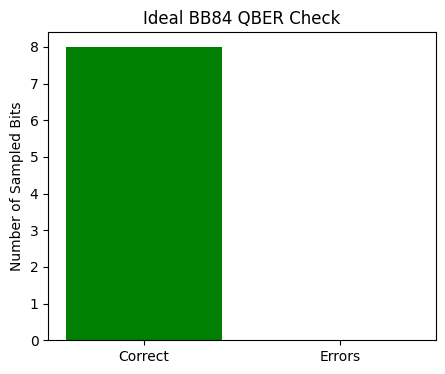

In [ ]:
#Simple QBER visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.bar(["Correct", "Errors"], [len(sampled_indices) - errors, errors], color=["green", "red"])
plt.title("Ideal BB84 QBER Check")
plt.ylabel("Number of Sampled Bits")
plt.show()

In [ ]:
# the above are the expected results for an ideal simulation with no noise or eavesdropping. 
# In a real hardware run, we would expect to see some errors and a non-zero QBER, which we will analyze in the next steps.


In [6]:
# Quantum hardware notebook for the same BB84 key-sharing flow.
import random
from typing import List, Tuple

from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

In [3]:
api_key = "ApiKey-149353d0-7f97-4543-8c62-7c818de81203"



In [4]:
#Step 1 on hardware, with simulator comparison
import random
from collections import Counter
from typing import List, Tuple

import matplotlib.pyplot as plt
import pandas as pd

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import PassManager
from qiskit.circuit.library import XGate

from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit_ibm_runtime.transpiler.passes.scheduling import (
    ASAPScheduleAnalysis,
    PadDynamicalDecoupling,
)

In [5]:
N = 8
SEED = 42
SHOTS = 256  # hardware stability check, not a literal one-shot BB84 transmission
USE_DD = True  # optional dynamical decoupling

In [6]:
def gen_bits_bases(n: int, seed: int) -> Tuple[List[int], List[int], List[int]]:
    rng = random.Random(seed)
    alice_bits = [rng.randint(0, 1) for _ in range(n)]
    alice_bases = [rng.randint(0, 1) for _ in range(n)]  # 0=Z, 1=X
    bob_bases = [rng.randint(0, 1) for _ in range(n)]    # 0=Z, 1=X
    return alice_bits, alice_bases, bob_bases

alice_bits, alice_bases, bob_bases = gen_bits_bases(N, SEED)

print("Alice bits: ", alice_bits)
print("Alice bases:", alice_bases)
print("Bob bases:  ", bob_bases)

Alice bits:  [0, 0, 1, 0, 0, 0, 0, 0]
Alice bases: [1, 0, 0, 0, 0, 0, 0, 0]
Bob bases:   [1, 0, 1, 1, 0, 0, 1, 1]


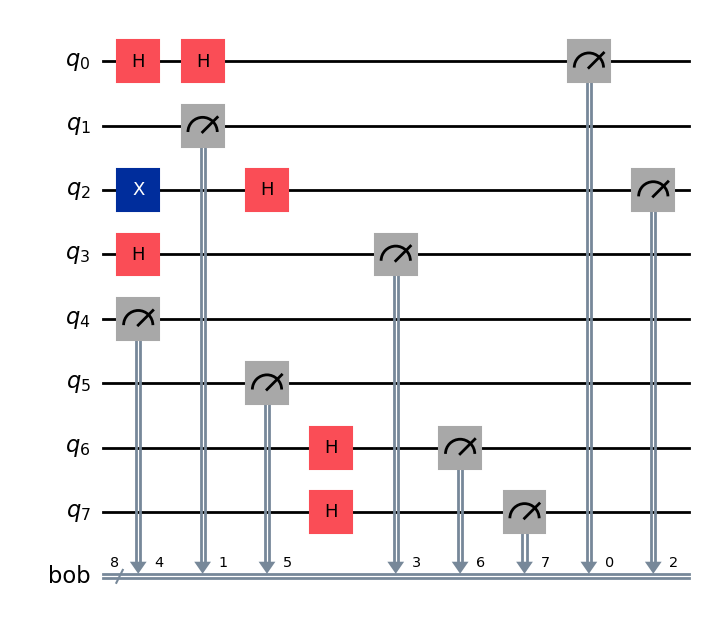

In [7]:
#Build the Step-1 BB84 circuit
def build_bb84_circuit(
    alice_bits: List[int],
    alice_bases: List[int],
    bob_bases: List[int],
) -> QuantumCircuit:
    n = len(alice_bits)

    q = QuantumRegister(n, "q")
    bob = ClassicalRegister(n, "bob")
    qc = QuantumCircuit(q, bob, name="bb84_step1_hw")

    # Alice prepares
    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(q[i])
        if alice_bases[i] == 1:
            qc.h(q[i])

    # Bob measures
    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(q[i])
        qc.measure(q[i], bob[i])

    return qc

qc = build_bb84_circuit(alice_bits, alice_bases, bob_bases)
qc.draw("mpl")

In [8]:
#Connect to IBM Quantum
# Assumes you already saved your credentials locally.
# If not, save them first using the IBM Quantum Platform account setup flow.


In [9]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

Quantum_api_key = "0FSSQimyq-69tArkrSOOziitEXLrpq2muR4n6o_vU-3B"
# Install packages (first time only)
# Connect to IBM Quantum
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",   # or "ibm_cloud" on the new platform
    token=Quantum_api_key,
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/00ca2aed1b3548b49d7381ffbdd25394:d3eb3467-58b7-416f-85ed-a47b073286da::"
)

qiskit_runtime_service._discover_account:WARNING:2026-03-13 10:47:28,722: Loading account with the given token. A saved account will not be used.


In [29]:
backend = service.least_busy(
    operational=True,
    simulator=False,
    min_num_qubits=N,
)

print("Selected backend:", backend.name)
print("Backend qubits:", backend.num_qubits)

Selected backend: ibm_fez
Backend qubits: 156


ISA circuit depth: 7
ISA circuit ops: OrderedDict({'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'barrier': 1})


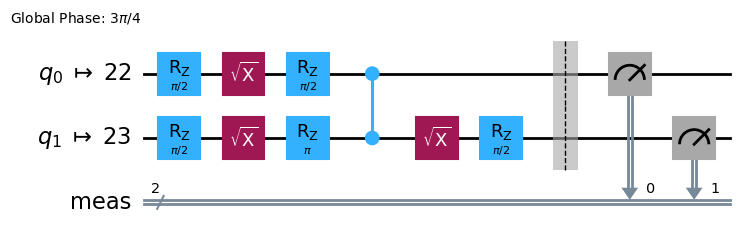

In [30]:
pm = generate_preset_pass_manager(
    optimization_level=3,
    backend=backend,
    seed_transpiler=SEED,
)

isa_circuit = pm.run(qc)
print("ISA circuit depth:", isa_circuit.depth())
print("ISA circuit ops:", isa_circuit.count_ops())

isa_circuit.draw("mpl", idle_wires=False)

Final circuit depth: 7
Final circuit ops: OrderedDict({'rz': 5, 'sx': 3, 'measure': 2, 'cz': 1, 'delay': 1, 'barrier': 1})


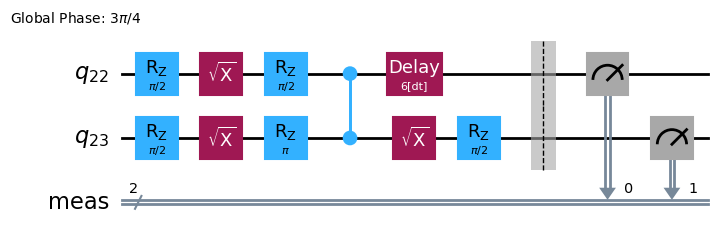

In [40]:
if USE_DD:
    durations = backend.target.durations()
    dd_sequence = [XGate(), XGate()]

    dd_pm = PassManager([
        ASAPScheduleAnalysis(durations),
        PadDynamicalDecoupling(durations, dd_sequence),
    ])

    final_circuit = dd_pm.run(isa_circuit)
else:
    final_circuit = isa_circuit

print("Final circuit depth:", final_circuit.depth())
print("Final circuit ops:", final_circuit.count_ops())

final_circuit.draw("mpl", idle_wires=False)


In [41]:
from collections import Counter
from typing import List


def normalize_bitstring(bitstring: str, n: int) -> str:
    """
    Convert a simulator count key into a full-length binary string of length n.
    Handles:
      - spaced binary strings
      - shortened binary strings
      - hex strings like '0x5'
    """
    bitstring = bitstring.strip()

    # Case 1: hex-style output
    if bitstring.startswith("0x"):
        value = int(bitstring, 16)
        return format(value, f"0{n}b")

    # Case 2: normal binary string (possibly with spaces)
    compact = bitstring.replace(" ", "")

    # Zero-pad if leading zeros were dropped
    if len(compact) < n:
        compact = compact.zfill(n)

    # Trim if unexpectedly longer
    if len(compact) > n:
        compact = compact[-n:]

    return compact


def majority_vote_bitstring(bitstrings: List[str], n: int) -> List[int]:
    """
    Convert many shot-level bitstrings into one inferred bitstring by majority vote per position.
    Qiskit bitstrings are MSB..LSB, so reverse each normalized string before indexing by qubit.
    """
    if not bitstrings:
        raise ValueError("No bitstrings received.")

    per_qubit_bits = [[] for _ in range(n)]

    for s in bitstrings:
        s_norm = normalize_bitstring(s, n)
        s_rev = s_norm[::-1]

        for i in range(n):
            per_qubit_bits[i].append(int(s_rev[i]))

    majority_bits = []
    for bits in per_qubit_bits:
        counts = Counter(bits)
        majority_bits.append(1 if counts[1] > counts[0] else 0)

    return majority_bits



In [42]:
sim = AerSimulator(seed_simulator=SEED)
sim_result = sim.run(final_circuit, shots=SHOTS).result()
sim_counts = sim_result.get_counts()

sim_bitstrings = []
for bitstring, count in sim_counts.items():
    sim_bitstrings.extend([bitstring] * count)

sim_bob_bits = majority_vote_bitstring(sim_bitstrings, N)
print("Simulator inferred Bob bits:", sim_bob_bits)

Simulator inferred Bob bits: [0, 0, 0, 0, 0, 0, 0, 0]


In [46]:
# Run on hardware with SamplerV2
sampler = Sampler(mode=backend)

job = sampler.run([final_circuit], shots=SHOTS)
print("Job ID:", job.job_id())

hw_result = job.result()
pub = hw_result[0]

# Universal extraction (works regardless of register name)
try:
    # Newer Runtime versions
    hw_counts = pub.data.meas.get_counts()
    hw_bitstrings = pub.data.meas.get_bitstrings()
except AttributeError:
    # Older / different container structure
    hw_counts = pub.data.get_counts()
    hw_bitstrings = []
    for bitstring, count in hw_counts.items():
        hw_bitstrings.extend([bitstring] * count)

# Convert to inferred bitstring
hw_bob_bits = majority_vote_bitstring(hw_bitstrings, N)
print("Hardware inferred Bob bits:", hw_bob_bits)

Job ID: d6mmpju9td6c73an77kg
Hardware inferred Bob bits: [0, 0, 0, 0, 0, 0, 0, 0]


In [47]:
# Cell 10 — Sift the keys
def sift(alice_bits, bob_bits, alice_bases, bob_bases):
    kept = [i for i in range(len(alice_bits)) if alice_bases[i] == bob_bases[i]]
    alice_key = [alice_bits[i] for i in kept]
    bob_key = [bob_bits[i] for i in kept]
    return kept, alice_key, bob_key


# ---- Simulator sifted keys ----
kept_sim, alice_key_sim, bob_key_sim = sift(
    alice_bits, sim_bob_bits, alice_bases, bob_bases
)

# ---- Hardware sifted keys ----
kept_hw, alice_key_hw, bob_key_hw = sift(
    alice_bits, hw_bob_bits, alice_bases, bob_bases
)

# These should be the same because kept positions depend only on the bases
assert kept_sim == kept_hw, "Kept indices differ unexpectedly."

kept = kept_sim

print("Kept idx:", kept)
print()

print("Alice sifted key (sim):", alice_key_sim)
print("Bob sifted key (sim):  ", bob_key_sim)
print("Simulator match?:      ", alice_key_sim == bob_key_sim)
print()

print("Alice sifted key (hw): ", alice_key_hw)
print("Bob sifted key (hw):   ", bob_key_hw)
print("Hardware match?:       ", alice_key_hw == bob_key_hw)
print()

print("Retention rate:", len(kept) / N if N else 0.0)

Kept idx: [0, 1, 4, 5]

Alice sifted key (sim): [0, 0, 0, 0]
Bob sifted key (sim):   [0, 0, 0, 0]
Simulator match?:       True

Alice sifted key (hw):  [0, 0, 0, 0]
Bob sifted key (hw):    [0, 0, 0, 0]
Hardware match?:        True

Retention rate: 0.5


In [48]:
#Compare simulator vs hardware QBER
def qber(alice_key, bob_key) -> float:
    if len(alice_key) == 0:
        return 0.0
    errors = sum(1 for a, b in zip(alice_key, bob_key) if a != b)
    return errors / len(alice_key)

sim_qber = qber(alice_key_sim, bob_key_sim)
hw_qber = qber(alice_key_hw, bob_key_hw)

metrics = {
    "n_qubits": N,
    "shots": SHOTS,
    "seed": SEED,
    "backend_name": backend.name,
    "retention_rate": len(kept) / N if N else 0.0,
    "sim_sifted_length": len(alice_key_sim),
    "hw_sifted_length": len(alice_key_hw),
    "sim_qber": sim_qber,
    "hw_qber": hw_qber,
    "sim_keys_match": alice_key_sim == bob_key_sim,
    "hw_keys_match": alice_key_hw == bob_key_hw,
}

metrics

{'n_qubits': 8,
 'shots': 256,
 'seed': 42,
 'backend_name': 'ibm_fez',
 'retention_rate': 0.5,
 'sim_sifted_length': 4,
 'hw_sifted_length': 4,
 'sim_qber': 0.0,
 'hw_qber': 0.0,
 'sim_keys_match': True,
 'hw_keys_match': True}

,Index,Alice Bit,Alice Basis,Bob Basis,Kept,Simulator Bob Bit,Hardware Bob Bit
0,0,0,1,1,True,0,0
1,1,0,0,0,True,0,0
2,2,1,0,1,False,0,0
3,3,0,0,1,False,0,0
4,4,0,0,0,True,0,0
5,5,0,0,0,True,0,0
6,6,0,0,1,False,0,0
7,7,0,0,1,False,0,0


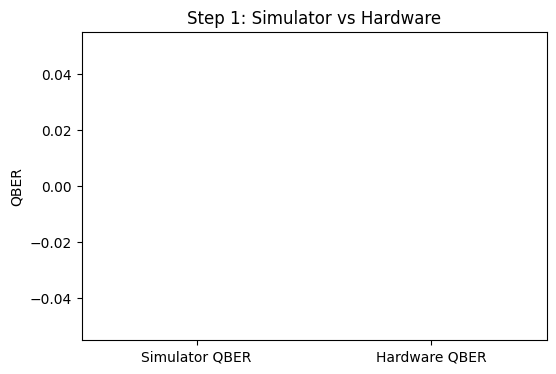

In [49]:
# visualize simularor vs hardware QBER
df = pd.DataFrame({
    "Index": list(range(N)),
    "Alice Bit": alice_bits,
    "Alice Basis": alice_bases,
    "Bob Basis": bob_bases,
    "Kept": [alice_bases[i] == bob_bases[i] for i in range(N)],
    "Simulator Bob Bit": sim_bob_bits,
    "Hardware Bob Bit": hw_bob_bits,
})

display(df)

plt.figure(figsize=(6, 4))
plt.bar(["Simulator QBER", "Hardware QBER"], [sim_qber, hw_qber], color=["green", "orange"])
plt.ylabel("QBER")
plt.title("Step 1: Simulator vs Hardware")
plt.show()

In [54]:
#src/bb84_core.py

from __future__ import annotations

import csv
import json
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator


@dataclass
class BB84ExperimentConfig:
    """Configuration for a BB84 circuit-level experiment."""

    n_qubits: int
    shots: int
    sample_size: int
    seed: int


@dataclass
class BB84ExperimentData:
    """Classical BB84 inputs shared across simulator and hardware runs."""

    alice_bits: list[int]
    alice_bases: list[int]
    bob_bases: list[int]


def generate_bits_and_bases(
    n: int,
    seed: int | None = None,
) -> BB84ExperimentData:
    """
    Generate Alice bits, Alice bases, and Bob bases.

    Basis convention:
        0 -> Z basis
        1 -> X basis
    """
    import random

    rng = random.Random(seed)

    alice_bits = [rng.randint(0, 1) for _ in range(n)]
    alice_bases = [rng.randint(0, 1) for _ in range(n)]
    bob_bases = [rng.randint(0, 1) for _ in range(n)]

    return BB84ExperimentData(
        alice_bits=alice_bits,
        alice_bases=alice_bases,
        bob_bases=bob_bases,
    )


def build_bb84_circuit(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> QuantumCircuit:
    """
    Build a single BB84 circuit with one qubit per raw-key position.

    Encoding:
        Z basis, bit 0 -> |0>
        Z basis, bit 1 -> |1>
        X basis, bit 0 -> |+>
        X basis, bit 1 -> |->
    """
    n = len(alice_bits)

    if not (len(alice_bases) == len(bob_bases) == n):
        raise ValueError("Input arrays must all have the same length.")

    qc = QuantumCircuit(n, n, name="bb84")

    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:
            qc.h(i)

    qc.barrier()

    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)

    qc.measure(range(n), range(n))
    return qc


def build_ideal_simulator() -> AerSimulator:
    """
    Build a local ideal simulator for BB84.

    The BB84 baseline circuit here uses only Clifford operations
    (X, H, measurement), so the stabilizer simulator is an efficient
    and appropriate exact method for this use case.
    """
    return AerSimulator(method="stabilizer")


def run_backend(
    circuit: QuantumCircuit,
    backend: AerSimulator,
    shots: int,
    seed_simulator: int | None = None,
) -> dict[str, int]:
    """
    Run a circuit on a local Aer simulator and return counts.

    Important:
    This function intentionally avoids transpiling against a backend target,
    because ideal local simulation should not inherit hardware qubit-count
    or coupling-map restrictions.
    """
    transpiled = transpile(
        circuit,
        seed_transpiler=seed_simulator,
        optimization_level=0,
    )

    job = backend.run(
        transpiled,
        shots=shots,
        seed_simulator=seed_simulator,
    )
    result = job.result()
    return result.get_counts()


def extract_bob_bits(
    counts: dict[str, int],
    n: int,
    shots: int,
) -> list[int]:
    """
    Extract one Bob bit per qubit by majority vote over repeated shots.

    Qiskit count strings are returned in big-endian classical-bit order,
    so we reverse the bitstring to align index i with qubit/classical bit i.
    """
    ones = [0] * n

    for bitstring, count in counts.items():
        cleaned = bitstring.replace(" ", "")
        reversed_bits = cleaned[::-1]

        if len(reversed_bits) != n:
            raise ValueError(
                f"Unexpected bitstring length {len(reversed_bits)}; expected {n}."
            )

        for i, char in enumerate(reversed_bits):
            if char == "1":
                ones[i] += count

    bob_bits = [1 if 2 * ones_i >= shots else 0 for ones_i in ones]
    return bob_bits


def sift_keys(
    alice_bits: list[int],
    bob_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> tuple[list[int], list[int], list[int]]:
    """
    Keep only positions where Alice and Bob used the same basis.

    Returns:
        alice_sifted, bob_sifted, kept_indices
    """
    alice_sifted: list[int] = []
    bob_sifted: list[int] = []
    kept_indices: list[int] = []

    for i, (a_bit, b_bit, a_basis, b_basis) in enumerate(
        zip(alice_bits, bob_bits, alice_bases, bob_bases)
    ):
        if a_basis == b_basis:
            alice_sifted.append(a_bit)
            bob_sifted.append(b_bit)
            kept_indices.append(i)

    return alice_sifted, bob_sifted, kept_indices


def estimate_qber(
    alice_sift: list[int],
    bob_sift: list[int],
    sample_size: int,
    seed: int | None = None,
) -> tuple[float, int, int]:
    """
    Estimate QBER on a random sample from the sifted key.
    """
    import random

    if len(alice_sift) != len(bob_sift):
        raise ValueError("Sifted keys must have equal length.")

    if len(alice_sift) == 0:
        return 0.0, 0, 0

    rng = random.Random(seed)
    actual_sample_size = min(sample_size, len(alice_sift))
    sample_indices = rng.sample(range(len(alice_sift)), actual_sample_size)

    errors = sum(
        1 for idx in sample_indices if alice_sift[idx] != bob_sift[idx]
    )
    qber = errors / actual_sample_size if actual_sample_size > 0 else 0.0
    return qber, errors, actual_sample_size


def simulate_intercept_resend(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
    seed: int | None = None,
) -> list[int]:
    """
    Classical intercept-resend model for sanity checking.
    """
    import random

    rng = random.Random(seed)
    n = len(alice_bits)

    eve_bases = [rng.randint(0, 1) for _ in range(n)]
    eve_bits: list[int] = []
    bob_bits: list[int] = []

    for i in range(n):
        if eve_bases[i] == alice_bases[i]:
            eve_bit = alice_bits[i]
        else:
            eve_bit = rng.randint(0, 1)
        eve_bits.append(eve_bit)

        if bob_bases[i] == eve_bases[i]:
            bob_bit = eve_bits[i]
        else:
            bob_bit = rng.randint(0, 1)
        bob_bits.append(bob_bit)

    return bob_bits


def apply_noise_model(backend_like: Any) -> AerSimulator:
    """
    Create an Aer simulator configured from a backend-like object.
    """
    return AerSimulator.from_backend(backend_like)


def summarize_metrics(
    *,
    n_qubits: int,
    shots: int,
    seed: int,
    backend_name: str,
    raw_key_length: int,
    sifted_key_length: int,
    sample_size: int,
    errors_in_sample: int,
    qber: float,
) -> dict[str, Any]:
    """
    Return structured metrics in publication-friendly dictionary form.
    """
    retention_rate = (
        sifted_key_length / raw_key_length if raw_key_length > 0 else 0.0
    )

    return {
        "n_qubits": n_qubits,
        "shots": shots,
        "seed": seed,
        "backend_name": backend_name,
        "raw_key_length": raw_key_length,
        "sifted_key_length": sifted_key_length,
        "retention_rate": retention_rate,
        "sample_size": sample_size,
        "errors_in_sample": errors_in_sample,
        "QBER": qber,
    }


def save_json(data: dict[str, Any], path: str | Path) -> None:
    """Save JSON with deterministic formatting."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def load_json(path: str | Path) -> dict[str, Any]:
    """Load JSON from disk."""
    return json.loads(Path(path).read_text(encoding="utf-8"))


def save_experiment_package(
    config: BB84ExperimentConfig,
    data: BB84ExperimentData,
    path: str | Path,
) -> None:
    """
    Save the exact experiment definition so hardware uses the same BB84 instance.
    """
    payload = {
        "config": asdict(config),
        "data": asdict(data),
    }
    save_json(payload, path)


def load_experiment_package(
    path: str | Path,
) -> tuple[BB84ExperimentConfig, BB84ExperimentData]:
    """
    Load experiment definition from disk.
    """
    payload = load_json(path)

    config = BB84ExperimentConfig(**payload["config"])
    data = BB84ExperimentData(**payload["data"])
    return config, data


def save_comparison_csv(
    *,
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
    kept_indices: list[int],
    simulator_bob_bits: list[int],
    hardware_bob_bits: list[int] | None,
    path: str | Path,
) -> None:
    """
    Save per-position comparison table for later analysis.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    kept_set = set(kept_indices)

    with path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.writer(handle)
        writer.writerow(
            [
                "Index",
                "Alice Bit",
                "Alice Basis",
                "Bob Basis",
                "Kept",
                "Simulator Bob Bit",
                "Hardware Bob Bit",
            ]
        )

        for i in range(len(alice_bits)):
            writer.writerow(
                [
                    i,
                    alice_bits[i],
                    alice_bases[i],
                    bob_bases[i],
                    i in kept_set,
                    simulator_bob_bits[i],
                    "" if hardware_bob_bits is None else hardware_bob_bits[i],
                ]
            )


def plot_comparative_qber(
    simulator_qber: float,
    hardware_qber: float,
    output_path: str | Path,
) -> None:
    """
    Plot simulator vs hardware QBER.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    labels = ["Simulator QBER", "Hardware QBER"]
    values = [simulator_qber, hardware_qber]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.ylabel("QBER")
    plt.title("Step 1: Simulator vs Hardware")
    plt.ylim(0.0, max(0.05, max(values) * 1.2 if values else 0.05))
    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.close()


def run_sanity_checks() -> None:
    """
    Validate core BB84 behavior on the ideal simulator and with a
    classical intercept-resend model.

    Keep this lightweight and local. It is a correctness check,
    not the full experiment.
    """
    config = BB84ExperimentConfig(
        n_qubits=32,
        shots=1024,
        sample_size=16,
        seed=42,
    )
    data = generate_bits_and_bases(config.n_qubits, seed=config.seed)

    backend = build_ideal_simulator()
    qc = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    counts = run_backend(
        circuit=qc,
        backend=backend,
        shots=config.shots,
        seed_simulator=config.seed,
    )
    bob_bits = extract_bob_bits(counts, config.n_qubits, config.shots)

    alice_sift, bob_sift, kept = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )
    qber, _, _ = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    retention_rate = len(kept) / config.n_qubits
    assert qber == 0.0, f"Ideal QBER should be 0.0, got {qber}"
    assert 0.25 <= retention_rate <= 0.75, (
        f"Sifting retention should be near 0.5, got {retention_rate:.3f}"
    )

    attacked_bob_bits = simulate_intercept_resend(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
        seed=config.seed,
    )
    attack_alice_sift, attack_bob_sift, _ = sift_keys(
        data.alice_bits,
        attacked_bob_bits,
        data.alice_bases,
        data.bob_bases,
    )
    attack_qber, _, _ = estimate_qber(
        attack_alice_sift,
        attack_bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    assert attack_qber > 0.10, (
        f"Attack QBER should be significantly higher than ideal, got {attack_qber:.3f}"
    )


if __name__ == "__main__":
    run_sanity_checks()

In [56]:
#run_bb84_simulator.py
from __future__ import annotations

from pathlib import Path



def main() -> None:
    """
    Run the BB84 baseline on an ideal local simulator.

    This script:
    1. performs lightweight sanity checks,
    2. generates a reproducible BB84 experiment package,
    3. runs the ideal simulator,
    4. computes sifted-key metrics and sampled QBER,
    5. saves outputs for later hardware comparison.
    """
    config = BB84ExperimentConfig(
        n_qubits=256,
        shots=4096,
        sample_size=64,
        seed=42,
    )

    output_dir = Path("outputs")
    output_dir.mkdir(parents=True, exist_ok=True)

    run_sanity_checks()

    data = generate_bits_and_bases(config.n_qubits, seed=config.seed)

    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    backend = build_ideal_simulator()

    counts = run_backend(
        circuit=circuit,
        backend=backend,
        shots=config.shots,
        seed_simulator=config.seed,
    )

    simulator_bob_bits = extract_bob_bits(
        counts=counts,
        n=config.n_qubits,
        shots=config.shots,
    )

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        simulator_bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    metrics = summarize_metrics(
        n_qubits=config.n_qubits,
        shots=config.shots,
        seed=config.seed,
        backend_name=str(backend.name),
        raw_key_length=config.n_qubits,
        sifted_key_length=len(alice_sift),
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    save_experiment_package(
        config=config,
        data=data,
        path=output_dir / "bb84_experiment_package.json",
    )

    save_json(
        {
            "metrics": metrics,
            "counts": counts,
            "bob_bits": simulator_bob_bits,
            "kept_indices": kept_indices,
        },
        output_dir / "simulator_results.json",
    )

    save_comparison_csv(
        alice_bits=data.alice_bits,
        alice_bases=data.alice_bases,
        bob_bases=data.bob_bases,
        kept_indices=kept_indices,
        simulator_bob_bits=simulator_bob_bits,
        hardware_bob_bits=None,
        path=output_dir / "bb84_comparison_partial.csv",
    )

    print(metrics)


if __name__ == "__main__":
    main()

{'n_qubits': 256, 'shots': 4096, 'seed': 42, 'backend_name': 'aer_simulator_stabilizer', 'raw_key_length': 256, 'sifted_key_length': 133, 'retention_rate': 0.51953125, 'sample_size': 64, 'errors_in_sample': 0, 'QBER': 0.0}


In [98]:
#experiments/run_bb84_hardware.py

from __future__ import annotations

from pathlib import Path
from typing import Any

from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2



def resolve_backend(
    service: QiskitRuntimeService,
    min_num_qubits: int,
    backend_name: str | None = None,
):
    """
    Resolve a target IBM Quantum hardware backend.

    If backend_name is provided, that backend is used directly.
    Otherwise the least busy eligible hardware backend is selected.
    """
    if backend_name is not None:
        return service.backend(backend_name)

    return service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=min_num_qubits,
    )


def validate_backend_capacity(backend: Any, required_qubits: int) -> None:
    """
    Raise a clear error if the selected backend cannot host the circuit width.
    """
    backend_qubits = int(backend.num_qubits)
    if backend_qubits < required_qubits:
        raise ValueError(
            f"Selected backend '{backend.name}' has {backend_qubits} qubits, "
            f"but the experiment requires {required_qubits} qubits."
        )

# new code 
def extract_counts_from_sampler_result(
    sampler_result: Any,
    circuit: QuantumCircuit,
) -> dict[str, int]:
    """
    Extract measurement counts from a SamplerV2 result using the circuit's
    actual classical register name.
    """
    pub_result = sampler_result[0]

    if len(circuit.cregs) == 0:
        raise ValueError("Circuit has no classical registers.")

    if len(circuit.cregs) > 1:
        raise ValueError(
            "This helper expects exactly one classical register. "
            f"Found {[creg.name for creg in circuit.cregs]}."
        )

    register_name = circuit.cregs[0].name

    try:
        register_data = getattr(pub_result.data, register_name)
    except AttributeError as exc:
        available = list(getattr(pub_result.data, "__dict__", {}).keys())
        raise AttributeError(
            f"Sampler result does not contain register '{register_name}'. "
            f"Available registers: {available}"
        ) from exc

    return register_data.get_counts()


def run_bb84_hardware_experiment(
    *,
    service: Any,
    backend_name: str | None = None,
    output_dir: str = "outputs",
) -> dict[str, Any]:
    """
    Run the saved BB84 experiment package on IBM Quantum hardware.
    """
    out_dir = Path(output_dir)
    package_path = out_dir / "bb84_experiment_package.json"
    simulator_results_path = out_dir / "simulator_results.json"

    if not package_path.exists():
        raise FileNotFoundError(
            "Missing bb84_experiment_package.json. Run the simulator experiment first."
        )

    if not simulator_results_path.exists():
        raise FileNotFoundError(
            "Missing simulator_results.json. Run the simulator experiment first."
        )

    config, data = load_experiment_package(package_path)
    simulator_results = load_json(simulator_results_path)

    simulator_metrics = simulator_results["metrics"]
    simulator_bob_bits = simulator_results["bob_bits"]

    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    backend = resolve_backend(
        service=service,
        min_num_qubits=config.n_qubits,
        backend_name=backend_name,
    )
    validate_backend_capacity(backend, config.n_qubits)

    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
    )
    isa_circuit = pass_manager.run(circuit)

    sampler = SamplerV2(mode=backend)
    job = sampler.run([isa_circuit], shots=config.shots)
    sampler_result = job.result()

    hardware_counts = extract_counts_from_sampler_result(
        sampler_result=sampler_result,
        circuit=circuit,
    )

    hardware_bob_bits = extract_bob_bits(
        counts=hardware_counts,
        n=config.n_qubits,
        shots=config.shots,
    )

    alice_sift, hardware_bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        hardware_bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    hardware_qber, hardware_errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        hardware_bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    hardware_metrics = summarize_metrics(
        n_qubits=config.n_qubits,
        shots=config.shots,
        seed=config.seed,
        backend_name=str(backend.name),
        raw_key_length=config.n_qubits,
        sifted_key_length=len(alice_sift),
        sample_size=actual_sample_size,
        errors_in_sample=hardware_errors_in_sample,
        qber=hardware_qber,
    )

    save_json(
        {
            "job_id": job.job_id(),
            "backend_name": str(backend.name),
            "metrics": hardware_metrics,
            "counts": hardware_counts,
            "bob_bits": hardware_bob_bits,
            "kept_indices": kept_indices,
        },
        out_dir / "hardware_results.json",
    )

    save_comparison_csv(
        alice_bits=data.alice_bits,
        alice_bases=data.alice_bases,
        bob_bases=data.bob_bases,
        kept_indices=kept_indices,
        simulator_bob_bits=simulator_bob_bits,
        hardware_bob_bits=hardware_bob_bits,
        path=out_dir / "bb84_comparison_full.csv",
    )

    plot_comparative_qber(
        simulator_qber=float(simulator_metrics["QBER"]),
        hardware_qber=float(hardware_metrics["QBER"]),
        output_path=out_dir / "step1_simulator_vs_hardware_qber.png",
    )

    summary = {
        "job_id": job.job_id(),
        "backend_name": str(backend.name),
        "metrics": hardware_metrics,
    }

    print(hardware_metrics)
    print(
        {
            "job_id": job.job_id(),
            "backend_name": str(backend.name),
        }
    )

    return summary

# end of the new code 



if __name__ == "__main__":
    raise RuntimeError(
        "This script now expects an externally created QiskitRuntimeService. "
        "Import main(...) from a notebook or another driver script and pass "
        "service=your_service."
    )

RuntimeError: This script now expects an externally created QiskitRuntimeService. Import main(...) from a notebook or another driver script and pass service=your_service.

In [61]:
# new code for notebook 
#imports
from __future__ import annotations

import csv
import json
import random
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2

In [ ]:
# Core data structures and helper functions


In [92]:
#Simulator run function
def run_bb84_simulator_experiment(
    *,
    n_qubits: int = 256,
    shots: int = 4096,
    sample_size: int = 64,
    seed: int = 42,
    output_dir: str = "outputs",
) -> dict[str, Any]:
    """
    Run the BB84 baseline on an ideal local simulator.

    Saves:
        - bb84_experiment_package.json
        - simulator_results.json
        - bb84_comparison_partial.csv
    """
    run_sanity_checks()

    config = BB84ExperimentConfig(
        n_qubits=n_qubits,
        shots=shots,
        sample_size=sample_size,
        seed=seed,
    )

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    data = generate_bits_and_bases(config.n_qubits, seed=config.seed)

    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    backend = build_ideal_simulator()

    counts = run_backend(
        circuit=circuit,
        backend=backend,
        shots=config.shots,
        seed_simulator=config.seed,
    )

    simulator_bob_bits = extract_bob_bits(
        counts=counts,
        n=config.n_qubits,
        shots=config.shots,
    )

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        simulator_bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    metrics = summarize_metrics(
        n_qubits=config.n_qubits,
        shots=config.shots,
        seed=config.seed,
        backend_name=str(backend.name),
        raw_key_length=config.n_qubits,
        sifted_key_length=len(alice_sift),
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    save_experiment_package(
        config=config,
        data=data,
        path=out_dir / "bb84_experiment_package.json",
    )

    save_json(
        {
            "metrics": metrics,
            "counts": counts,
            "bob_bits": simulator_bob_bits,
            "kept_indices": kept_indices,
        },
        out_dir / "simulator_results.json",
    )

    save_comparison_csv(
        alice_bits=data.alice_bits,
        alice_bases=data.alice_bases,
        bob_bases=data.bob_bases,
        kept_indices=kept_indices,
        simulator_bob_bits=simulator_bob_bits,
        hardware_bob_bits=None,
        path=out_dir / "bb84_comparison_partial.csv",
    )

    print(metrics)
    return {
        "config": config,
        "data": data,
        "metrics": metrics,
        "counts": counts,
        "bob_bits": simulator_bob_bits,
        "kept_indices": kept_indices,
        "circuit": circuit,
    }

In [99]:
config, data = load_experiment_package("outputs/bb84_experiment_package.json")
qc = build_bb84_circuit(data.alice_bits, data.alice_bases, data.bob_bases)
print(qc.cregs)
print([creg.name for creg in qc.cregs])

[ClassicalRegister(30, 'c')]
['c']


In [93]:
#Hardware run function
def run_bb84_hardware_experiment(
    *,
    service: Any,
    backend_name: str | None = None,
    output_dir: str = "outputs",
) -> dict[str, Any]:
    """
    Run the saved BB84 experiment package on IBM Quantum hardware.

    Expects:
        - a pre-created `service` object in the notebook
        - simulator outputs already saved in `output_dir`

    Saves:
        - hardware_results.json
        - bb84_comparison_full.csv
        - step1_simulator_vs_hardware_qber.png
    """
    out_dir = Path(output_dir)
    package_path = out_dir / "bb84_experiment_package.json"
    simulator_results_path = out_dir / "simulator_results.json"

    if not package_path.exists():
        raise FileNotFoundError(
            "Missing bb84_experiment_package.json. Run the simulator experiment first."
        )

    if not simulator_results_path.exists():
        raise FileNotFoundError(
            "Missing simulator_results.json. Run the simulator experiment first."
        )

    config, data = load_experiment_package(package_path)
    simulator_results = load_json(simulator_results_path)

    simulator_metrics = simulator_results["metrics"]
    simulator_bob_bits = simulator_results["bob_bits"]

    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    backend = resolve_backend(
        service=service,
        min_num_qubits=config.n_qubits,
        backend_name=backend_name,
    )
    validate_backend_capacity(backend, config.n_qubits)

    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
    )
    isa_circuit = pass_manager.run(circuit)

    sampler = SamplerV2(mode=backend)
    job = sampler.run([isa_circuit], shots=config.shots)
    sampler_result = job.result()

    hardware_counts = extract_counts_from_sampler_result(
        sampler_result=sampler_result,
        register_name="meas",
    )

    hardware_bob_bits = extract_bob_bits(
        counts=hardware_counts,
        n=config.n_qubits,
        shots=config.shots,
    )

    alice_sift, hardware_bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        hardware_bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    hardware_qber, hardware_errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        hardware_bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    hardware_metrics = summarize_metrics(
        n_qubits=config.n_qubits,
        shots=config.shots,
        seed=config.seed,
        backend_name=str(backend.name),
        raw_key_length=config.n_qubits,
        sifted_key_length=len(alice_sift),
        sample_size=actual_sample_size,
        errors_in_sample=hardware_errors_in_sample,
        qber=hardware_qber,
    )

    save_json(
        {
            "job_id": job.job_id(),
            "backend_name": str(backend.name),
            "metrics": hardware_metrics,
            "counts": hardware_counts,
            "bob_bits": hardware_bob_bits,
            "kept_indices": kept_indices,
        },
        out_dir / "hardware_results.json",
    )

    save_comparison_csv(
        alice_bits=data.alice_bits,
        alice_bases=data.alice_bases,
        bob_bases=data.bob_bases,
        kept_indices=kept_indices,
        simulator_bob_bits=simulator_bob_bits,
        hardware_bob_bits=hardware_bob_bits,
        path=out_dir / "bb84_comparison_full.csv",
    )

    plot_comparative_qber(
        simulator_qber=float(simulator_metrics["QBER"]),
        hardware_qber=float(hardware_metrics["QBER"]),
        output_path=out_dir / "step1_simulator_vs_hardware_qber.png",
    )

    summary = {
        "job_id": job.job_id(),
        "backend_name": str(backend.name),
        "metrics": hardware_metrics,
    }

    print(hardware_metrics)
    print(
        {
            "job_id": job.job_id(),
            "backend_name": str(backend.name),
        }
    )

    return summary

In [100]:
#Optional: inspect available backends
def list_candidate_backends(service: Any, min_num_qubits: int = 1) -> list[tuple[str, int]]:
    """
    List operational, non-simulator backends meeting a qubit threshold.
    """
    backends = service.backends(
        operational=True,
        simulator=False,
        min_num_qubits=min_num_qubits,
    )

    result = sorted(
        [(backend.name, int(backend.num_qubits)) for backend in backends],
        key=lambda item: (item[1], item[0]),
    )

    for name, qubits in result:
        print(f"{name}: {qubits} qubits")

    return result

In [101]:
#Run the simulator first
sim_result = run_bb84_simulator_experiment(
    n_qubits=30,
    shots=4096,
    sample_size=64,
    seed=42,
    output_dir="outputs",
)

{'n_qubits': 30, 'shots': 4096, 'seed': 42, 'backend_name': 'aer_simulator_stabilizer', 'raw_key_length': 30, 'sifted_key_length': 16, 'retention_rate': 0.5333333333333333, 'sample_size': 16, 'errors_in_sample': 0, 'QBER': 0.0}


In [102]:
#Check hardware capacity before running
candidate_backends = list_candidate_backends(service, min_num_qubits=256)

In [103]:
candidate_backends

[]

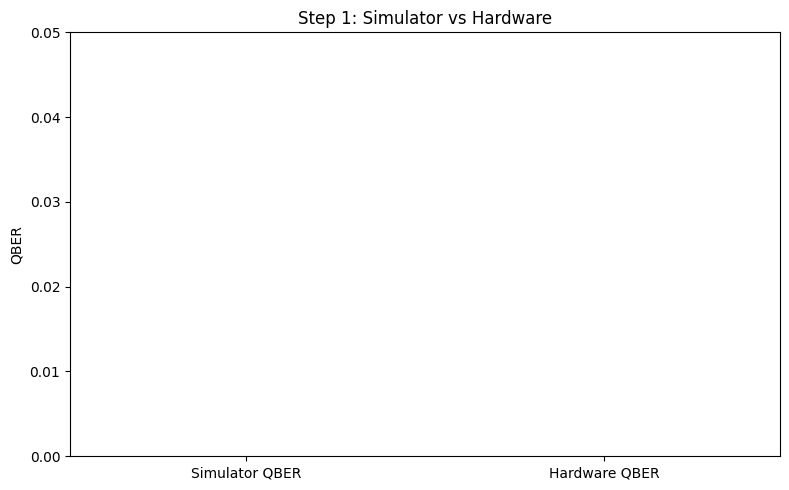

{'n_qubits': 30, 'shots': 4096, 'seed': 42, 'backend_name': 'ibm_fez', 'raw_key_length': 30, 'sifted_key_length': 16, 'retention_rate': 0.5333333333333333, 'sample_size': 16, 'errors_in_sample': 0, 'QBER': 0.0}
{'job_id': 'd6mpe5e9td6c73ana49g', 'backend_name': 'ibm_fez'}


In [104]:
#Run on hardware
hw_result = run_bb84_hardware_experiment(
    service=service,
    backend_name=None,
    output_dir="outputs",
)

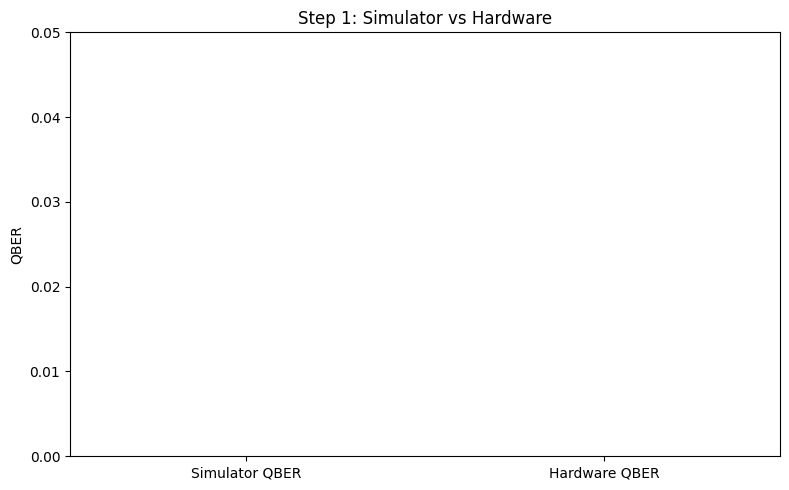

{'n_qubits': 30, 'shots': 4096, 'seed': 42, 'backend_name': 'ibm_marrakesh', 'raw_key_length': 30, 'sifted_key_length': 16, 'retention_rate': 0.5333333333333333, 'sample_size': 16, 'errors_in_sample': 0, 'QBER': 0.0}
{'job_id': 'd6mpeas3pels73a0nvmg', 'backend_name': 'ibm_marrakesh'}


In [105]:
hw_result = run_bb84_hardware_experiment(
    service=service,
    backend_name="ibm_marrakesh",
    output_dir="outputs",
)

In [ ]:
simulator_results = load_json("outputs/simulator_results.json")
hardware_results = load_json("outputs/hardware_results.json")

print("Simulator metrics:")
print(simulator_results["metrics"])
print("\nHardware metrics:")
print(hardware_results["metrics"])

Simulator metrics:
{'n_qubits': 30, 'shots': 4096, 'seed': 42, 'backend_name': 'aer_simulator_stabilizer', 'raw_key_length': 30, 'sifted_key_length': 16, 'retention_rate': 0.5333333333333333, 'sample_size': 16, 'errors_in_sample': 0, 'QBER': 0.0}

Hardware metrics:
{'n_qubits': 30, 'shots': 4096, 'seed': 42, 'backend_name': 'ibm_marrakesh', 'raw_key_length': 30, 'sifted_key_length': 16, 'retention_rate': 0.5333333333333333, 'sample_size': 16, 'errors_in_sample': 0, 'QBER': 0.0}


## Iteration 2 

In [123]:
# imports
from __future__ import annotations

import csv
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2

In [124]:
#Data structures
@dataclass
class BB84ExperimentConfig:
    """Configuration for a BB84 circuit-level experiment."""
    n_qubits: int
    shots: int
    sample_size: int
    seed: int


@dataclass
class BB84ExperimentData:
    """Classical BB84 inputs shared across experiment modes."""
    alice_bits: list[int]
    alice_bases: list[int]
    bob_bases: list[int]

In [126]:
# Core BB84 helpers
#
def generate_bits_and_bases(
    n: int,
    seed: int | None = None,
) -> BB84ExperimentData:
    """
    Generate Alice bits, Alice bases, and Bob bases.

    Basis convention:
        0 -> Z basis
        1 -> X basis
    """
    rng = random.Random(seed)

    alice_bits = [rng.randint(0, 1) for _ in range(n)]
    alice_bases = [rng.randint(0, 1) for _ in range(n)]
    bob_bases = [rng.randint(0, 1) for _ in range(n)]

    return BB84ExperimentData(
        alice_bits=alice_bits,
        alice_bases=alice_bases,
        bob_bases=bob_bases,
    )


def build_bb84_circuit(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> QuantumCircuit:
    """
    Build a BB84 circuit with one qubit per raw-key position.

    Encoding:
        Z basis, bit 0 -> |0>
        Z basis, bit 1 -> |1>
        X basis, bit 0 -> |+>
        X basis, bit 1 -> |->
    """
    n = len(alice_bits)

    if not (len(alice_bases) == len(bob_bases) == n):
        raise ValueError("Input arrays must all have the same length.")

    qc = QuantumCircuit(n, n, name="bb84")

    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:
            qc.h(i)

    qc.barrier()

    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)

    qc.measure(range(n), range(n))
    return qc


def build_ideal_simulator() -> AerSimulator:
    """
    Build a local ideal simulator.

    This BB84 baseline uses only X, H, and measurement,
    so stabilizer simulation is appropriate.
    """
    return AerSimulator(method="stabilizer")


def build_noisy_simulator_from_backend(backend: Any) -> AerSimulator:
    """
    Build a backend-derived noisy simulator.
    """
    return AerSimulator.from_backend(backend)


def run_local_simulator(
    circuit: QuantumCircuit,
    backend: AerSimulator,
    shots: int,
    seed_simulator: int | None = None,
) -> dict[str, int]:
    """
    Run on a local ideal Aer simulator.

    Important:
    Do not transpile against backend=backend here, so the ideal path
    does not inherit hardware coupling-map restrictions.
    """
    transpiled = transpile(
        circuit,
        seed_transpiler=seed_simulator,
        optimization_level=0,
    )

    job = backend.run(
        transpiled,
        shots=shots,
        seed_simulator=seed_simulator,
    )
    result = job.result()
    return result.get_counts()


def extract_bob_bits(
    counts: dict[str, int],
    n: int,
    shots: int,
) -> list[int]:
    """
    Extract one Bob bit per qubit by majority vote across repeated shots.

    Qiskit count strings use big-endian classical-bit order, so reverse
    each bitstring so index i matches qubit/classical bit i.
    """
    ones = [0] * n

    for bitstring, count in counts.items():
        cleaned = bitstring.replace(" ", "")
        reversed_bits = cleaned[::-1]

        if len(reversed_bits) != n:
            raise ValueError(
                f"Unexpected bitstring length {len(reversed_bits)}; expected {n}."
            )

        for i, char in enumerate(reversed_bits):
            if char == "1":
                ones[i] += count

    return [1 if 2 * value >= shots else 0 for value in ones]


def sift_keys(
    alice_bits: list[int],
    bob_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> tuple[list[int], list[int], list[int]]:
    """
    Keep only positions where Alice and Bob used the same basis.

    Returns:
        alice_sifted, bob_sifted, kept_indices
    """
    alice_sifted: list[int] = []
    bob_sifted: list[int] = []
    kept_indices: list[int] = []

    for i, (a_bit, b_bit, a_basis, b_basis) in enumerate(
        zip(alice_bits, bob_bits, alice_bases, bob_bases)
    ):
        if a_basis == b_basis:
            alice_sifted.append(a_bit)
            bob_sifted.append(b_bit)
            kept_indices.append(i)

    return alice_sifted, bob_sifted, kept_indices


def estimate_qber(
    alice_sift: list[int],
    bob_sift: list[int],
    sample_size: int,
    seed: int | None = None,
) -> tuple[float, int, int]:
    """
    Estimate QBER on a random sample from the sifted key.
    """
    if len(alice_sift) != len(bob_sift):
        raise ValueError("Sifted keys must have equal length.")

    if len(alice_sift) == 0:
        return 0.0, 0, 0

    rng = random.Random(seed)
    actual_sample_size = min(sample_size, len(alice_sift))
    sample_indices = rng.sample(range(len(alice_sift)), actual_sample_size)

    errors = sum(
        1 for idx in sample_indices if alice_sift[idx] != bob_sift[idx]
    )
    qber = errors / actual_sample_size if actual_sample_size > 0 else 0.0
    return qber, errors, actual_sample_size


def simulate_intercept_resend(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
    seed: int | None = None,
) -> list[int]:
    """
    Classical intercept-resend model for sanity checking.
    """
    rng = random.Random(seed)
    n = len(alice_bits)

    eve_bases = [rng.randint(0, 1) for _ in range(n)]
    eve_bits: list[int] = []
    bob_bits: list[int] = []

    for i in range(n):
        if eve_bases[i] == alice_bases[i]:
            eve_bit = alice_bits[i]
        else:
            eve_bit = rng.randint(0, 1)
        eve_bits.append(eve_bit)

        if bob_bases[i] == eve_bases[i]:
            bob_bit = eve_bits[i]
        else:
            bob_bit = rng.randint(0, 1)
        bob_bits.append(bob_bit)

    return bob_bits


def count_kept_mismatches(
    alice_sift: list[int],
    bob_sift: list[int],
) -> tuple[int, float]:
    """
    Count mismatches on the full sifted key.
    """
    if len(alice_sift) != len(bob_sift):
        raise ValueError("Sifted keys must have equal length.")

    if len(alice_sift) == 0:
        return 0, 0.0

    mismatch_count = sum(
        1 for a_bit, b_bit in zip(alice_sift, bob_sift) if a_bit != b_bit
    )
    mismatch_rate = mismatch_count / len(alice_sift)
    return mismatch_count, mismatch_rate

In [128]:
# Persistence, summary, validation, and backend helpers
# Result extraction, backend helpers, sanity checks
def extract_counts_from_pub_result(pub_result: Any) -> dict[str, int]:
    """
    Extract counts robustly from a sampler pub result.

    Works for both Runtime SamplerV2 and Aer SamplerV2 results.
    """
    if hasattr(pub_result, "join_data"):
        return pub_result.join_data().get_counts()

    data_obj = pub_result.data
    data_dict = getattr(data_obj, "__dict__", {})

    if not data_dict:
        raise ValueError("Unable to extract counts from sampler pub result.")

    first_key = next(iter(data_dict))
    register_data = getattr(data_obj, first_key)
    return register_data.get_counts()


def extract_counts_from_sampler_result(
    sampler_result: Any,
) -> dict[str, int]:
    """
    Extract counts from a sampler result container.
    """
    pub_result = sampler_result[0]
    return extract_counts_from_pub_result(pub_result)


def summarize_metrics(
    *,
    trial: int,
    mode: str,
    n_qubits: int,
    shots: int,
    seed: int,
    backend_name: str,
    raw_key_length: int,
    sifted_key_length: int,
    kept_mismatch_count: int,
    kept_mismatch_rate: float,
    sample_size: int,
    errors_in_sample: int,
    qber: float,
) -> dict[str, Any]:
    """
    Return structured metrics.
    """
    retention_rate = (
        sifted_key_length / raw_key_length if raw_key_length > 0 else 0.0
    )

    return {
        "trial": trial,
        "mode": mode,
        "n_qubits": n_qubits,
        "shots": shots,
        "seed": seed,
        "backend_name": backend_name,
        "raw_key_length": raw_key_length,
        "sifted_key_length": sifted_key_length,
        "retention_rate": retention_rate,
        "kept_mismatch_count": kept_mismatch_count,
        "kept_mismatch_rate": kept_mismatch_rate,
        "sample_size": sample_size,
        "errors_in_sample": errors_in_sample,
        "QBER": qber,
    }


def save_json(data: dict[str, Any], path: str | Path) -> None:
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def save_trial_metrics_csv(
    rows: list[dict[str, Any]],
    path: str | Path,
) -> None:
    """
    Save per-trial metrics to CSV.
    """
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not rows:
        raise ValueError("No rows provided for CSV export.")

    fieldnames = list(rows[0].keys())

    with output_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def resolve_backend(
    service: Any,
    min_num_qubits: int,
    backend_name: str | None = None,
):
    """
    Resolve a target IBM Quantum hardware backend.
    """
    if backend_name is not None:
        return service.backend(backend_name)

    return service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=min_num_qubits,
    )


def validate_backend_capacity(backend: Any, required_qubits: int) -> None:
    """
    Raise a clear error if the selected backend cannot host the circuit width.
    """
    backend_qubits = int(backend.num_qubits)
    if backend_qubits < required_qubits:
        raise ValueError(
            f"Selected backend '{backend.name}' has {backend_qubits} qubits, "
            f"but the experiment requires {required_qubits} qubits."
        )


def list_candidate_backends(
    service: Any,
    min_num_qubits: int = 1,
) -> list[tuple[str, int]]:
    """
    List operational, non-simulator backends meeting a qubit threshold.
    """
    backends = service.backends(
        operational=True,
        simulator=False,
        min_num_qubits=min_num_qubits,
    )

    result = sorted(
        [(backend.name, int(backend.num_qubits)) for backend in backends],
        key=lambda item: (item[1], item[0]),
    )

    for name, qubits in result:
        print(f"{name}: {qubits} qubits")

    return result


def run_sanity_checks() -> None:
    """
    Lightweight correctness checks.
    """
    config = BB84ExperimentConfig(
        n_qubits=32,
        shots=1024,
        sample_size=16,
        seed=42,
    )
    data = generate_bits_and_bases(config.n_qubits, seed=config.seed)

    backend = build_ideal_simulator()
    qc = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )
    counts = run_local_simulator(
        circuit=qc,
        backend=backend,
        shots=config.shots,
        seed_simulator=config.seed,
    )
    bob_bits = extract_bob_bits(counts, config.n_qubits, config.shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )
    qber, _, _ = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    retention_rate = len(kept_indices) / config.n_qubits
    assert qber == 0.0, f"Ideal QBER should be 0.0, got {qber}"
    assert 0.25 <= retention_rate <= 0.75, (
        f"Sifting retention should be near 0.5, got {retention_rate:.3f}"
    )

    attacked_bob_bits = simulate_intercept_resend(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
        seed=config.seed,
    )
    attack_alice_sift, attack_bob_sift, _ = sift_keys(
        data.alice_bits,
        attacked_bob_bits,
        data.alice_bases,
        data.bob_bases,
    )
    attack_qber, _, _ = estimate_qber(
        attack_alice_sift,
        attack_bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    assert attack_qber > 0.10, (
        f"Attack QBER should be significantly higher than ideal, got {attack_qber:.3f}"
    )

In [129]:
# single trail runners  

def run_single_ideal_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
) -> dict[str, Any]:
    """
    Run one ideal simulator BB84 trial.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    backend = build_ideal_simulator()
    counts = run_local_simulator(
        circuit=circuit,
        backend=backend,
        shots=shots,
        seed_simulator=seed,
    )
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="ideal",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
    }


def run_single_noisy_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
) -> dict[str, Any]:
    """
    Run one backend-derived noisy simulator BB84 trial.

    Uses Aer SamplerV2 with a simulator configured from the selected backend.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    noisy_sim = build_noisy_simulator_from_backend(backend)

    # Transpile to the noisy simulator target.
    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=noisy_sim,
    )
    isa_circuit = pass_manager.run(circuit)

    noisy_sampler = AerSamplerV2(mode=noisy_sim)

    # PUB format for SamplerV2: (circuit, parameter_values, shots)
    pub = (isa_circuit, None, shots)
    job = noisy_sampler.run([pub])
    result = job.result()

    counts = extract_counts_from_pub_result(result[0])
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="noisy_sim",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=f"noisy_sim_from_{backend.name}",
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
    }


def run_single_hardware_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
) -> dict[str, Any]:
    """
    Run one hardware BB84 trial on an already selected backend.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
    )
    isa_circuit = pass_manager.run(circuit)

    sampler = SamplerV2(mode=backend)
    job = sampler.run([isa_circuit], shots=shots)
    sampler_result = job.result()

    counts = extract_counts_from_sampler_result(sampler_result)
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="hardware",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
        "job_id": job.job_id(),
    }

In [113]:
#One-trial execution helpers
def run_single_ideal_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
) -> dict[str, Any]:
    """
    Run one ideal simulator BB84 trial.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    backend = build_ideal_simulator()
    counts = run_local_simulator(
        circuit=circuit,
        backend=backend,
        shots=shots,
        seed_simulator=seed,
    )
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="ideal",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
    }


def run_single_noisy_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
) -> dict[str, Any]:
    """
    Run one backend-derived noisy simulator BB84 trial.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    noisy_backend = build_noisy_simulator_from_backend(backend)

    transpiled = transpile(
        circuit,
        backend=backend,
        seed_transpiler=seed,
        optimization_level=1,
    )

    job = noisy_backend.run(
        transpiled,
        shots=shots,
        seed_simulator=seed,
    )
    result = job.result()
    counts = result.get_counts()

    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="noisy_sim",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=f"noisy_sim_from_{backend.name}",
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
    }


def run_single_hardware_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
    sampler_options: dict[str, Any] | None = None,
) -> dict[str, Any]:
    """
    Run one hardware BB84 trial on an already selected backend.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
    )
    isa_circuit = pass_manager.run(circuit)

    sampler = SamplerV2(mode=backend)

    if sampler_options:
        for option_name, option_value in sampler_options.items():
            setattr(sampler.options, option_name, option_value)

    job = sampler.run([isa_circuit], shots=shots)
    sampler_result = job.result()

    counts = extract_counts_from_sampler_result(sampler_result)
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="hardware",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
        "job_id": job.job_id(),
    }

In [130]:
# Summary and plotting helper  
def summarize_iteration_2_results(
    rows: list[dict[str, Any]],
) -> dict[str, Any]:
    """
    Compute aggregate statistics by mode.
    """
    grouped: dict[str, list[dict[str, Any]]] = {}

    for row in rows:
        grouped.setdefault(row["mode"], []).append(row)

    summary: dict[str, Any] = {}

    for mode, mode_rows in grouped.items():
        qbers = [float(row["QBER"]) for row in mode_rows]
        retention_rates = [float(row["retention_rate"]) for row in mode_rows]
        kept_mismatch_rates = [float(row["kept_mismatch_rate"]) for row in mode_rows]
        sifted_lengths = [int(row["sifted_key_length"]) for row in mode_rows]

        summary[mode] = {
            "num_trials": len(mode_rows),
            "mean_qber": sum(qbers) / len(qbers),
            "mean_retention_rate": sum(retention_rates) / len(retention_rates),
            "mean_kept_mismatch_rate": (
                sum(kept_mismatch_rates) / len(kept_mismatch_rates)
            ),
            "mean_sifted_key_length": sum(sifted_lengths) / len(sifted_lengths),
            "max_qber": max(qbers),
            "min_qber": min(qbers),
        }

    return summary


def plot_iteration_2_results(
    rows: list[dict[str, Any]],
    output_dir: str | Path,
) -> None:
    """
    Generate comparison plots.
    """
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    grouped: dict[str, list[dict[str, Any]]] = {}
    for row in rows:
        grouped.setdefault(row["mode"], []).append(row)

    mode_order = [mode for mode in ["ideal", "noisy_sim", "hardware"] if mode in grouped]

    plt.figure(figsize=(10, 5))
    for mode in mode_order:
        mode_rows = sorted(grouped[mode], key=lambda item: int(item["trial"]))
        x_vals = [int(row["trial"]) for row in mode_rows]
        y_vals = [float(row["QBER"]) for row in mode_rows]
        plt.plot(x_vals, y_vals, marker="o", label=mode)

    plt.xlabel("Trial")
    plt.ylabel("QBER")
    plt.title("Iteration 2: QBER by Trial")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_qber_by_trial.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    mean_qbers = [
        sum(float(row["QBER"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_qbers)
    plt.xlabel("Mode")
    plt.ylabel("Mean QBER")
    plt.title("Iteration 2: Mean QBER by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_qber.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    mean_retention = [
        sum(float(row["retention_rate"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_retention)
    plt.xlabel("Mode")
    plt.ylabel("Mean Retention Rate")
    plt.title("Iteration 2: Mean Retention Rate by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_retention.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    mean_kept_mismatch = [
        sum(float(row["kept_mismatch_rate"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_kept_mismatch)
    plt.xlabel("Mode")
    plt.ylabel("Mean Kept Mismatch Rate")
    plt.title("Iteration 2: Mean Kept Mismatch Rate by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_kept_mismatch.png", dpi=300)
    plt.show()

In [131]:
# Main Iteration 2 runner
def run_iteration_2_experiment(
    *,
    service: Any,
    n_qubits: int = 30,
    shots: int = 4096,
    sample_size: int = 16,
    num_trials: int = 10,
    base_seed: int = 42,
    backend_name: str | None = None,
    run_hardware: bool = True,
    output_dir: str = "outputs_iteration_2",
) -> dict[str, Any]:
    """
    Run Iteration 2:
        ideal simulator vs noisy simulator vs hardware

    Notes:
    - uses identical seeds across all modes
    - uses a hardware-friendly default width
    - exports per-trial metrics and plots
    """
    run_sanity_checks()

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    backend = resolve_backend(
        service=service,
        min_num_qubits=n_qubits,
        backend_name=backend_name,
    )
    validate_backend_capacity(backend, n_qubits)

    all_rows: list[dict[str, Any]] = []
    detailed_results: list[dict[str, Any]] = []

    for trial in range(num_trials):
        seed = base_seed + trial

        ideal_result = run_single_ideal_trial(
            trial=trial,
            n_qubits=n_qubits,
            shots=shots,
            sample_size=sample_size,
            seed=seed,
        )

        noisy_result = run_single_noisy_trial(
            trial=trial,
            n_qubits=n_qubits,
            shots=shots,
            sample_size=sample_size,
            seed=seed,
            backend=backend,
        )

        all_rows.append(ideal_result["metrics"])
        all_rows.append(noisy_result["metrics"])

        trial_detail = {
            "trial": trial,
            "seed": seed,
            "ideal": ideal_result["metrics"],
            "noisy_sim": noisy_result["metrics"],
        }

        if run_hardware:
            hardware_result = run_single_hardware_trial(
                trial=trial,
                n_qubits=n_qubits,
                shots=shots,
                sample_size=sample_size,
                seed=seed,
                backend=backend,
            )
            all_rows.append(hardware_result["metrics"])
            trial_detail["hardware"] = hardware_result["metrics"]
            trial_detail["hardware_job_id"] = hardware_result["job_id"]

        detailed_results.append(trial_detail)

        print(
            {
                "trial": trial,
                "seed": seed,
                "ideal_qber": ideal_result["metrics"]["QBER"],
                "noisy_qber": noisy_result["metrics"]["QBER"],
                "hardware_qber": (
                    None if not run_hardware else hardware_result["metrics"]["QBER"]
                ),
            }
        )

    save_trial_metrics_csv(
        rows=all_rows,
        path=out_dir / "iteration_2_trial_metrics.csv",
    )

    save_json(
        {
            "config": {
                "n_qubits": n_qubits,
                "shots": shots,
                "sample_size": sample_size,
                "num_trials": num_trials,
                "base_seed": base_seed,
                "backend_name": str(backend.name),
                "run_hardware": run_hardware,
            },
            "trial_results": detailed_results,
        },
        out_dir / "iteration_2_results.json",
    )

    summary = summarize_iteration_2_results(all_rows)
    save_json(summary, out_dir / "iteration_2_summary.json")

    plot_iteration_2_results(
        rows=all_rows,
        output_dir=out_dir,
    )

    print("\nSummary:")
    print(summary)

    return {
        "backend_name": str(backend.name),
        "rows": all_rows,
        "summary": summary,
        "details": detailed_results,
    }

In [132]:
# Optional backed check 
candidate_backends = list_candidate_backends(service, min_num_qubits=30)

ibm_torino: 133 qubits
ibm_fez: 156 qubits
ibm_marrakesh: 156 qubits


In [133]:
iteration_2_result = run_iteration_2_experiment(
    service=service,
    n_qubits=30,
    shots=4096,
    sample_size=16,
    num_trials=10,
    base_seed=42,
    backend_name="ibm_marrakesh",
    run_hardware=True,
    output_dir="outputs_iteration_2",
)

TypeError: SamplerV2.__init__() got an unexpected keyword argument 'mode'

In [115]:
#Summary and plotting helpers
def summarize_iteration_2_results(
    rows: list[dict[str, Any]],
) -> dict[str, Any]:
    """
    Compute aggregate statistics by mode.
    """
    grouped: dict[str, list[dict[str, Any]]] = {}

    for row in rows:
        grouped.setdefault(row["mode"], []).append(row)

    summary: dict[str, Any] = {}

    for mode, mode_rows in grouped.items():
        qbers = [float(row["QBER"]) for row in mode_rows]
        retention_rates = [float(row["retention_rate"]) for row in mode_rows]
        kept_mismatch_rates = [float(row["kept_mismatch_rate"]) for row in mode_rows]
        sifted_lengths = [int(row["sifted_key_length"]) for row in mode_rows]

        summary[mode] = {
            "num_trials": len(mode_rows),
            "mean_qber": sum(qbers) / len(qbers),
            "mean_retention_rate": sum(retention_rates) / len(retention_rates),
            "mean_kept_mismatch_rate": (
                sum(kept_mismatch_rates) / len(kept_mismatch_rates)
            ),
            "mean_sifted_key_length": sum(sifted_lengths) / len(sifted_lengths),
            "max_qber": max(qbers),
            "min_qber": min(qbers),
        }

    return summary


def plot_iteration_2_results(
    rows: list[dict[str, Any]],
    output_dir: str | Path,
) -> None:
    """
    Generate publication-friendly comparison plots.
    """
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    grouped: dict[str, list[dict[str, Any]]] = {}
    for row in rows:
        grouped.setdefault(row["mode"], []).append(row)

    mode_order = [mode for mode in ["ideal", "noisy_sim", "hardware"] if mode in grouped]

    # Plot 1: QBER by trial
    plt.figure(figsize=(10, 5))
    for mode in mode_order:
        mode_rows = sorted(grouped[mode], key=lambda item: int(item["trial"]))
        x_vals = [int(row["trial"]) for row in mode_rows]
        y_vals = [float(row["QBER"]) for row in mode_rows]
        plt.plot(x_vals, y_vals, marker="o", label=mode)

    plt.xlabel("Trial")
    plt.ylabel("QBER")
    plt.title("Iteration 2: QBER by Trial")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_qber_by_trial.png", dpi=300)
    plt.show()

    # Plot 2: Mean QBER by mode
    plt.figure(figsize=(8, 5))
    mean_qbers = [
        sum(float(row["QBER"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_qbers)
    plt.xlabel("Mode")
    plt.ylabel("Mean QBER")
    plt.title("Iteration 2: Mean QBER by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_qber.png", dpi=300)
    plt.show()

    # Plot 3: Mean retention rate by mode
    plt.figure(figsize=(8, 5))
    mean_retention = [
        sum(float(row["retention_rate"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_retention)
    plt.xlabel("Mode")
    plt.ylabel("Mean Retention Rate")
    plt.title("Iteration 2: Mean Retention Rate by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_retention.png", dpi=300)
    plt.show()

    # Plot 4: Mean kept mismatch rate by mode
    plt.figure(figsize=(8, 5))
    mean_kept_mismatch = [
        sum(float(row["kept_mismatch_rate"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_kept_mismatch)
    plt.xlabel("Mode")
    plt.ylabel("Mean Kept Mismatch Rate")
    plt.title("Iteration 2: Mean Kept Mismatch Rate by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_kept_mismatch.png", dpi=300)
    plt.show()

In [116]:
#Recommended first Iteration 2 run
candidate_backends = list_candidate_backends(service, min_num_qubits=30)

ibm_torino: 133 qubits
ibm_fez: 156 qubits
ibm_marrakesh: 156 qubits


In [134]:
# Iteration 2 execution 
from __future__ import annotations
import csv
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2

In [135]:
@dataclass
class BB84ExperimentConfig:
    """Configuration for a BB84 circuit-level experiment."""
    n_qubits: int
    shots: int
    sample_size: int
    seed: int


@dataclass
class BB84ExperimentData:
    """Classical BB84 inputs shared across experiment modes."""
    alice_bits: list[int]
    alice_bases: list[int]
    bob_bases: list[int]

In [136]:
def generate_bits_and_bases(
    n: int,
    seed: int | None = None,
) -> BB84ExperimentData:
    """
    Generate Alice bits, Alice bases, and Bob bases.

    Basis convention:
        0 -> Z basis
        1 -> X basis
    """
    rng = random.Random(seed)

    alice_bits = [rng.randint(0, 1) for _ in range(n)]
    alice_bases = [rng.randint(0, 1) for _ in range(n)]
    bob_bases = [rng.randint(0, 1) for _ in range(n)]

    return BB84ExperimentData(
        alice_bits=alice_bits,
        alice_bases=alice_bases,
        bob_bases=bob_bases,
    )


def build_bb84_circuit(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> QuantumCircuit:
    """
    Build a BB84 circuit with one qubit per raw-key position.
    """
    n = len(alice_bits)

    if not (len(alice_bases) == len(bob_bases) == n):
        raise ValueError("Input arrays must all have the same length.")

    qc = QuantumCircuit(n, n, name="bb84")

    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:
            qc.h(i)

    qc.barrier()

    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)

    qc.measure(range(n), range(n))
    return qc


def build_ideal_simulator() -> AerSimulator:
    """
    Build a local ideal simulator.

    This BB84 baseline uses only X, H, and measurement,
    so stabilizer simulation is appropriate.
    """
    return AerSimulator(method="stabilizer")


def build_noisy_simulator_from_backend(backend: Any) -> AerSimulator:
    """
    Build a backend-derived noisy simulator.

    AerSimulator.from_backend(...) copies a basic device noise model,
    coupling map, and basis gates from the backend.
    """
    return AerSimulator.from_backend(backend)


def run_local_simulator(
    circuit: QuantumCircuit,
    backend: AerSimulator,
    shots: int,
    seed_simulator: int | None = None,
) -> dict[str, int]:
    """
    Run on a local ideal Aer simulator.

    Do not transpile against backend=backend here, so the ideal path
    does not inherit hardware coupling-map restrictions.
    """
    transpiled = transpile(
        circuit,
        seed_transpiler=seed_simulator,
        optimization_level=0,
    )

    job = backend.run(
        transpiled,
        shots=shots,
        seed_simulator=seed_simulator,
    )
    result = job.result()
    return result.get_counts(0)


def extract_bob_bits(
    counts: dict[str, int],
    n: int,
    shots: int,
) -> list[int]:
    """
    Extract one Bob bit per qubit by majority vote across repeated shots.
    """
    ones = [0] * n

    for bitstring, count in counts.items():
        cleaned = bitstring.replace(" ", "")
        reversed_bits = cleaned[::-1]

        if len(reversed_bits) != n:
            raise ValueError(
                f"Unexpected bitstring length {len(reversed_bits)}; expected {n}."
            )

        for i, char in enumerate(reversed_bits):
            if char == "1":
                ones[i] += count

    return [1 if 2 * value >= shots else 0 for value in ones]


def sift_keys(
    alice_bits: list[int],
    bob_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> tuple[list[int], list[int], list[int]]:
    """
    Keep only positions where Alice and Bob used the same basis.
    """
    alice_sifted: list[int] = []
    bob_sifted: list[int] = []
    kept_indices: list[int] = []

    for i, (a_bit, b_bit, a_basis, b_basis) in enumerate(
        zip(alice_bits, bob_bits, alice_bases, bob_bases)
    ):
        if a_basis == b_basis:
            alice_sifted.append(a_bit)
            bob_sifted.append(b_bit)
            kept_indices.append(i)

    return alice_sifted, bob_sifted, kept_indices


def estimate_qber(
    alice_sift: list[int],
    bob_sift: list[int],
    sample_size: int,
    seed: int | None = None,
) -> tuple[float, int, int]:
    """
    Estimate QBER on a random sample from the sifted key.
    """
    if len(alice_sift) != len(bob_sift):
        raise ValueError("Sifted keys must have equal length.")

    if len(alice_sift) == 0:
        return 0.0, 0, 0

    rng = random.Random(seed)
    actual_sample_size = min(sample_size, len(alice_sift))
    sample_indices = rng.sample(range(len(alice_sift)), actual_sample_size)

    errors = sum(
        1 for idx in sample_indices if alice_sift[idx] != bob_sift[idx]
    )
    qber = errors / actual_sample_size if actual_sample_size > 0 else 0.0
    return qber, errors, actual_sample_size


def simulate_intercept_resend(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
    seed: int | None = None,
) -> list[int]:
    """
    Classical intercept-resend model for sanity checking.
    """
    rng = random.Random(seed)
    n = len(alice_bits)

    eve_bases = [rng.randint(0, 1) for _ in range(n)]
    eve_bits: list[int] = []
    bob_bits: list[int] = []

    for i in range(n):
        if eve_bases[i] == alice_bases[i]:
            eve_bit = alice_bits[i]
        else:
            eve_bit = rng.randint(0, 1)
        eve_bits.append(eve_bit)

        if bob_bases[i] == eve_bases[i]:
            bob_bit = eve_bits[i]
        else:
            bob_bit = rng.randint(0, 1)
        bob_bits.append(bob_bit)

    return bob_bits


def count_kept_mismatches(
    alice_sift: list[int],
    bob_sift: list[int],
) -> tuple[int, float]:
    """
    Count mismatches on the full sifted key.
    """
    if len(alice_sift) != len(bob_sift):
        raise ValueError("Sifted keys must have equal length.")

    if len(alice_sift) == 0:
        return 0, 0.0

    mismatch_count = sum(
        1 for a_bit, b_bit in zip(alice_sift, bob_sift) if a_bit != b_bit
    )
    mismatch_rate = mismatch_count / len(alice_sift)
    return mismatch_count, mismatch_rate

In [137]:
def extract_counts_from_pub_result(pub_result: Any) -> dict[str, int]:
    """
    Extract counts robustly from a sampler pub result.

    Sampler V2 results are organized by classical-register data.
    """
    if hasattr(pub_result, "join_data"):
        joined = pub_result.join_data()
        if hasattr(joined, "get_counts"):
            return joined.get_counts()

    data_obj = pub_result.data

    if hasattr(data_obj, "__dict__") and data_obj.__dict__:
        first_key = next(iter(data_obj.__dict__))
        register_data = getattr(data_obj, first_key)
        if hasattr(register_data, "get_counts"):
            return register_data.get_counts()

    raise ValueError("Unable to extract counts from sampler pub result.")


def extract_counts_from_sampler_result(
    sampler_result: Any,
) -> dict[str, int]:
    """
    Extract counts from a sampler result container.
    """
    pub_result = sampler_result[0]
    return extract_counts_from_pub_result(pub_result)


def summarize_metrics(
    *,
    trial: int,
    mode: str,
    n_qubits: int,
    shots: int,
    seed: int,
    backend_name: str,
    raw_key_length: int,
    sifted_key_length: int,
    kept_mismatch_count: int,
    kept_mismatch_rate: float,
    sample_size: int,
    errors_in_sample: int,
    qber: float,
) -> dict[str, Any]:
    """
    Return structured metrics.
    """
    retention_rate = (
        sifted_key_length / raw_key_length if raw_key_length > 0 else 0.0
    )

    return {
        "trial": trial,
        "mode": mode,
        "n_qubits": n_qubits,
        "shots": shots,
        "seed": seed,
        "backend_name": backend_name,
        "raw_key_length": raw_key_length,
        "sifted_key_length": sifted_key_length,
        "retention_rate": retention_rate,
        "kept_mismatch_count": kept_mismatch_count,
        "kept_mismatch_rate": kept_mismatch_rate,
        "sample_size": sample_size,
        "errors_in_sample": errors_in_sample,
        "QBER": qber,
    }


def save_json(data: dict[str, Any], path: str | Path) -> None:
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def save_trial_metrics_csv(
    rows: list[dict[str, Any]],
    path: str | Path,
) -> None:
    """
    Save per-trial metrics to CSV.
    """
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not rows:
        raise ValueError("No rows provided for CSV export.")

    fieldnames = list(rows[0].keys())

    with output_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def resolve_backend(
    service: Any,
    min_num_qubits: int,
    backend_name: str | None = None,
):
    """
    Resolve a target IBM Quantum hardware backend.
    """
    if backend_name is not None:
        return service.backend(backend_name)

    return service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=min_num_qubits,
    )


def validate_backend_capacity(backend: Any, required_qubits: int) -> None:
    """
    Raise a clear error if the selected backend cannot host the circuit width.
    """
    backend_qubits = int(backend.num_qubits)
    if backend_qubits < required_qubits:
        raise ValueError(
            f"Selected backend '{backend.name}' has {backend_qubits} qubits, "
            f"but the experiment requires {required_qubits} qubits."
        )


def list_candidate_backends(
    service: Any,
    min_num_qubits: int = 1,
) -> list[tuple[str, int]]:
    """
    List operational, non-simulator backends meeting a qubit threshold.
    """
    backends = service.backends(
        operational=True,
        simulator=False,
        min_num_qubits=min_num_qubits,
    )

    result = sorted(
        [(backend.name, int(backend.num_qubits)) for backend in backends],
        key=lambda item: (item[1], item[0]),
    )

    for name, qubits in result:
        print(f"{name}: {qubits} qubits")

    return result


def run_sanity_checks() -> None:
    """
    Lightweight correctness checks.
    """
    config = BB84ExperimentConfig(
        n_qubits=32,
        shots=1024,
        sample_size=16,
        seed=42,
    )
    data = generate_bits_and_bases(config.n_qubits, seed=config.seed)

    backend = build_ideal_simulator()
    qc = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )
    counts = run_local_simulator(
        circuit=qc,
        backend=backend,
        shots=config.shots,
        seed_simulator=config.seed,
    )
    bob_bits = extract_bob_bits(counts, config.n_qubits, config.shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )
    qber, _, _ = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    retention_rate = len(kept_indices) / config.n_qubits
    assert qber == 0.0, f"Ideal QBER should be 0.0, got {qber}"
    assert 0.25 <= retention_rate <= 0.75, (
        f"Sifting retention should be near 0.5, got {retention_rate:.3f}"
    )

    attacked_bob_bits = simulate_intercept_resend(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
        seed=config.seed,
    )
    attack_alice_sift, attack_bob_sift, _ = sift_keys(
        data.alice_bits,
        attacked_bob_bits,
        data.alice_bases,
        data.bob_bases,
    )
    attack_qber, _, _ = estimate_qber(
        attack_alice_sift,
        attack_bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    assert attack_qber > 0.10, (
        f"Attack QBER should be significantly higher than ideal, got {attack_qber:.3f}"
    )

In [138]:
def run_single_ideal_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
) -> dict[str, Any]:
    """
    Run one ideal simulator BB84 trial.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    backend = build_ideal_simulator()
    counts = run_local_simulator(
        circuit=circuit,
        backend=backend,
        shots=shots,
        seed_simulator=seed,
    )
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="ideal",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
    }


def run_single_noisy_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
) -> dict[str, Any]:
    """
    Run one backend-derived noisy simulator BB84 trial.

    Uses a backend-derived Aer simulator together with BackendSamplerV2.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    noisy_sim = build_noisy_simulator_from_backend(backend)

    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=noisy_sim,
    )
    isa_circuit = pass_manager.run(circuit)

    noisy_sampler = BackendSamplerV2(backend=noisy_sim)
    job = noisy_sampler.run([(isa_circuit, None, shots)])
    sampler_result = job.result()

    counts = extract_counts_from_sampler_result(sampler_result)
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="noisy_sim",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=f"noisy_sim_from_{backend.name}",
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
    }


def run_single_hardware_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
) -> dict[str, Any]:
    """
    Run one hardware BB84 trial on an already selected backend.
    """
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
    )
    isa_circuit = pass_manager.run(circuit)

    sampler = SamplerV2(mode=backend)
    job = sampler.run([isa_circuit], shots=shots)
    sampler_result = job.result()

    counts = extract_counts_from_sampler_result(sampler_result)
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="hardware",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "kept_indices": kept_indices,
        "job_id": job.job_id(),
    }

In [139]:
def summarize_iteration_2_results(
    rows: list[dict[str, Any]],
) -> dict[str, Any]:
    """
    Compute aggregate statistics by mode.
    """
    grouped: dict[str, list[dict[str, Any]]] = {}

    for row in rows:
        grouped.setdefault(row["mode"], []).append(row)

    summary: dict[str, Any] = {}

    for mode, mode_rows in grouped.items():
        qbers = [float(row["QBER"]) for row in mode_rows]
        retention_rates = [float(row["retention_rate"]) for row in mode_rows]
        kept_mismatch_rates = [float(row["kept_mismatch_rate"]) for row in mode_rows]
        sifted_lengths = [int(row["sifted_key_length"]) for row in mode_rows]

        summary[mode] = {
            "num_trials": len(mode_rows),
            "mean_qber": sum(qbers) / len(qbers),
            "mean_retention_rate": sum(retention_rates) / len(retention_rates),
            "mean_kept_mismatch_rate": (
                sum(kept_mismatch_rates) / len(kept_mismatch_rates)
            ),
            "mean_sifted_key_length": sum(sifted_lengths) / len(sifted_lengths),
            "max_qber": max(qbers),
            "min_qber": min(qbers),
        }

    return summary


def plot_iteration_2_results(
    rows: list[dict[str, Any]],
    output_dir: str | Path,
) -> None:
    """
    Generate comparison plots.
    """
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    grouped: dict[str, list[dict[str, Any]]] = {}
    for row in rows:
        grouped.setdefault(row["mode"], []).append(row)

    mode_order = [mode for mode in ["ideal", "noisy_sim", "hardware"] if mode in grouped]

    plt.figure(figsize=(10, 5))
    for mode in mode_order:
        mode_rows = sorted(grouped[mode], key=lambda item: int(item["trial"]))
        x_vals = [int(row["trial"]) for row in mode_rows]
        y_vals = [float(row["QBER"]) for row in mode_rows]
        plt.plot(x_vals, y_vals, marker="o", label=mode)

    plt.xlabel("Trial")
    plt.ylabel("QBER")
    plt.title("Iteration 2: QBER by Trial")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_qber_by_trial.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    mean_qbers = [
        sum(float(row["QBER"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_qbers)
    plt.xlabel("Mode")
    plt.ylabel("Mean QBER")
    plt.title("Iteration 2: Mean QBER by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_qber.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    mean_retention = [
        sum(float(row["retention_rate"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_retention)
    plt.xlabel("Mode")
    plt.ylabel("Mean Retention Rate")
    plt.title("Iteration 2: Mean Retention Rate by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_retention.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    mean_kept_mismatch = [
        sum(float(row["kept_mismatch_rate"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_kept_mismatch)
    plt.xlabel("Mode")
    plt.ylabel("Mean Kept Mismatch Rate")
    plt.title("Iteration 2: Mean Kept Mismatch Rate by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_2_mean_kept_mismatch.png", dpi=300)
    plt.show()

In [140]:
def run_iteration_2_experiment(
    *,
    service: Any,
    n_qubits: int = 30,
    shots: int = 4096,
    sample_size: int = 16,
    num_trials: int = 10,
    base_seed: int = 42,
    backend_name: str | None = None,
    run_hardware: bool = True,
    output_dir: str = "outputs_iteration_2",
) -> dict[str, Any]:
    """
    Run Iteration 2:
        ideal simulator vs noisy simulator vs hardware
    """
    run_sanity_checks()

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    backend = resolve_backend(
        service=service,
        min_num_qubits=n_qubits,
        backend_name=backend_name,
    )
    validate_backend_capacity(backend, n_qubits)

    all_rows: list[dict[str, Any]] = []
    detailed_results: list[dict[str, Any]] = []

    for trial in range(num_trials):
        seed = base_seed + trial

        ideal_result = run_single_ideal_trial(
            trial=trial,
            n_qubits=n_qubits,
            shots=shots,
            sample_size=sample_size,
            seed=seed,
        )

        noisy_result = run_single_noisy_trial(
            trial=trial,
            n_qubits=n_qubits,
            shots=shots,
            sample_size=sample_size,
            seed=seed,
            backend=backend,
        )

        all_rows.append(ideal_result["metrics"])
        all_rows.append(noisy_result["metrics"])

        trial_detail = {
            "trial": trial,
            "seed": seed,
            "ideal": ideal_result["metrics"],
            "noisy_sim": noisy_result["metrics"],
        }

        if run_hardware:
            hardware_result = run_single_hardware_trial(
                trial=trial,
                n_qubits=n_qubits,
                shots=shots,
                sample_size=sample_size,
                seed=seed,
                backend=backend,
            )
            all_rows.append(hardware_result["metrics"])
            trial_detail["hardware"] = hardware_result["metrics"]
            trial_detail["hardware_job_id"] = hardware_result["job_id"]

        detailed_results.append(trial_detail)

        print(
            {
                "trial": trial,
                "seed": seed,
                "ideal_qber": ideal_result["metrics"]["QBER"],
                "noisy_qber": noisy_result["metrics"]["QBER"],
                "hardware_qber": (
                    None if not run_hardware else hardware_result["metrics"]["QBER"]
                ),
            }
        )

    save_trial_metrics_csv(
        rows=all_rows,
        path=out_dir / "iteration_2_trial_metrics.csv",
    )

    save_json(
        {
            "config": {
                "n_qubits": n_qubits,
                "shots": shots,
                "sample_size": sample_size,
                "num_trials": num_trials,
                "base_seed": base_seed,
                "backend_name": str(backend.name),
                "run_hardware": run_hardware,
            },
            "trial_results": detailed_results,
        },
        out_dir / "iteration_2_results.json",
    )

    summary = summarize_iteration_2_results(all_rows)
    save_json(summary, out_dir / "iteration_2_summary.json")

    plot_iteration_2_results(
        rows=all_rows,
        output_dir=out_dir,
    )

    print("\nSummary:")
    print(summary)

    return {
        "backend_name": str(backend.name),
        "rows": all_rows,
        "summary": summary,
        "details": detailed_results,
    }

In [141]:
candidate_backends = list_candidate_backends(service, min_num_qubits=30)

ibm_torino: 133 qubits
ibm_fez: 156 qubits
ibm_marrakesh: 156 qubits


{'trial': 0, 'seed': 42, 'ideal_qber': 0.0, 'noisy_qber': 0.1875, 'hardware_qber': 0.0625}
{'trial': 1, 'seed': 43, 'ideal_qber': 0.0, 'noisy_qber': 0.18181818181818182, 'hardware_qber': 0.0}
{'trial': 2, 'seed': 44, 'ideal_qber': 0.0, 'noisy_qber': 0.5833333333333334, 'hardware_qber': 0.0}
{'trial': 3, 'seed': 45, 'ideal_qber': 0.0, 'noisy_qber': 0.5714285714285714, 'hardware_qber': 0.0}
{'trial': 4, 'seed': 46, 'ideal_qber': 0.0, 'noisy_qber': 0.625, 'hardware_qber': 0.0}
{'trial': 5, 'seed': 47, 'ideal_qber': 0.0, 'noisy_qber': 0.5333333333333333, 'hardware_qber': 0.0}
{'trial': 6, 'seed': 48, 'ideal_qber': 0.0, 'noisy_qber': 0.3333333333333333, 'hardware_qber': 0.0}
{'trial': 7, 'seed': 49, 'ideal_qber': 0.0, 'noisy_qber': 0.4375, 'hardware_qber': 0.0}
{'trial': 8, 'seed': 50, 'ideal_qber': 0.0, 'noisy_qber': 0.46153846153846156, 'hardware_qber': 0.0}
{'trial': 9, 'seed': 51, 'ideal_qber': 0.0, 'noisy_qber': 0.625, 'hardware_qber': 0.0}


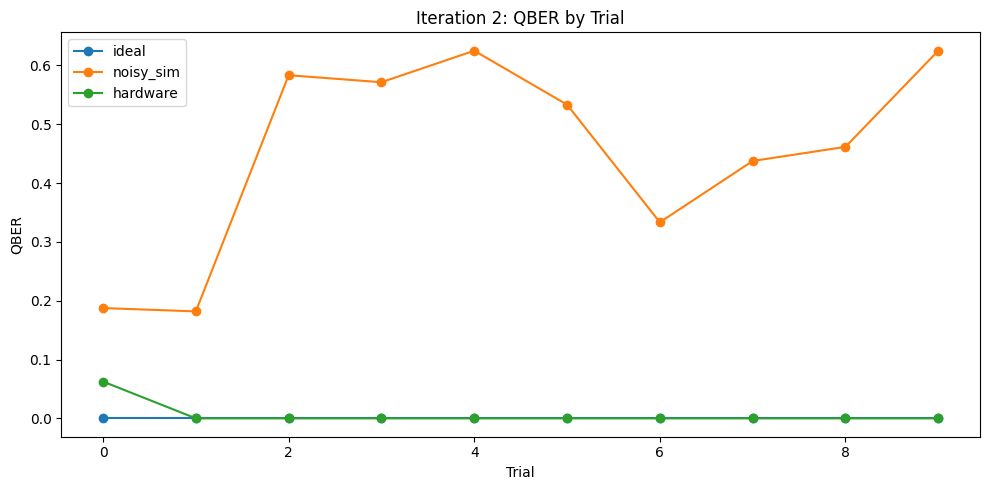

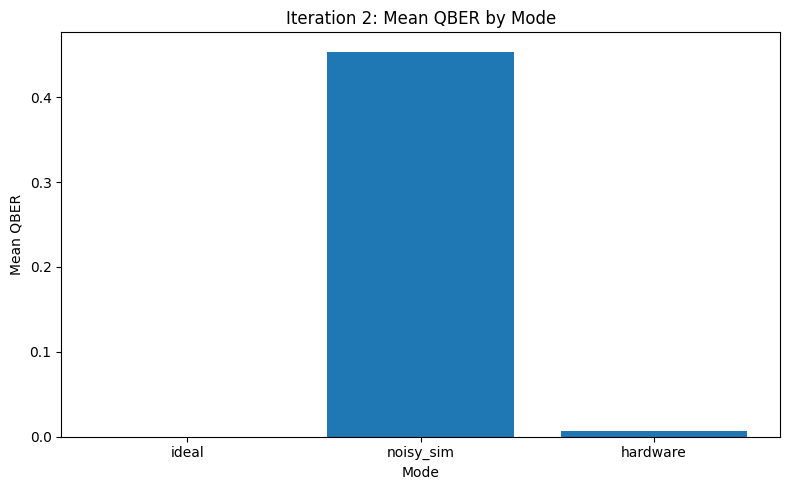

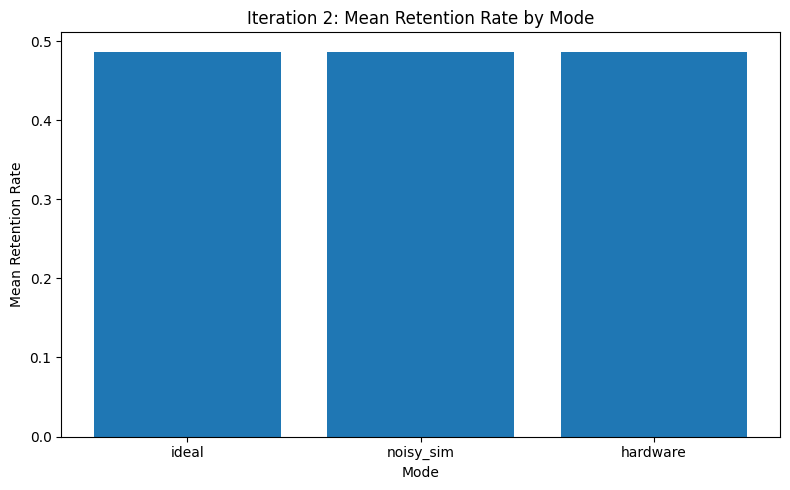

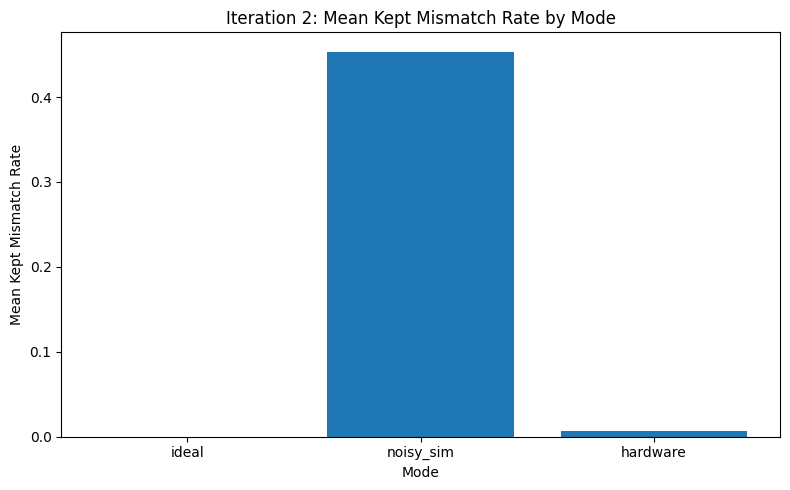


Summary:
{'ideal': {'num_trials': 10, 'mean_qber': 0.0, 'mean_retention_rate': 0.48666666666666664, 'mean_kept_mismatch_rate': 0.0, 'mean_sifted_key_length': 14.6, 'max_qber': 0.0, 'min_qber': 0.0}, 'noisy_sim': {'num_trials': 10, 'mean_qber': 0.45397852147852147, 'mean_retention_rate': 0.48666666666666664, 'mean_kept_mismatch_rate': 0.45361087441969794, 'mean_sifted_key_length': 14.6, 'max_qber': 0.625, 'min_qber': 0.18181818181818182}, 'hardware': {'num_trials': 10, 'mean_qber': 0.00625, 'mean_retention_rate': 0.48666666666666664, 'mean_kept_mismatch_rate': 0.00625, 'mean_sifted_key_length': 14.6, 'max_qber': 0.0625, 'min_qber': 0.0}}


In [142]:
iteration_2_result = run_iteration_2_experiment(
    service=service,
    n_qubits=30,
    shots=4096,
    sample_size=16,
    num_trials=10,
    base_seed=42,
    backend_name="ibm_marrakesh",
    run_hardware=True,
    output_dir="outputs_iteration_2",
)

In [143]:
# Imports 
from __future__ import annotations

import csv
import json
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2

In [144]:
# Data structures
@dataclass
class BB84ExperimentConfig:
    """Configuration for a BB84 circuit-level experiment."""
    n_qubits: int
    shots: int
    sample_size: int
    seed: int


@dataclass
class BB84ExperimentData:
    """Classical BB84 inputs shared across experiment modes."""
    alice_bits: list[int]
    alice_bases: list[int]
    bob_bases: list[int]

In [145]:
# Core BB84 helpers 
def generate_bits_and_bases(
    n: int,
    seed: int | None = None,
) -> BB84ExperimentData:
    """
    Generate Alice bits, Alice bases, and Bob bases.

    Basis convention:
        0 -> Z basis
        1 -> X basis
    """
    rng = random.Random(seed)

    alice_bits = [rng.randint(0, 1) for _ in range(n)]
    alice_bases = [rng.randint(0, 1) for _ in range(n)]
    bob_bases = [rng.randint(0, 1) for _ in range(n)]

    return BB84ExperimentData(
        alice_bits=alice_bits,
        alice_bases=alice_bases,
        bob_bases=bob_bases,
    )


def build_bb84_circuit(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> QuantumCircuit:
    """
    Build a BB84 circuit with one qubit per raw-key position.
    """
    n = len(alice_bits)

    if not (len(alice_bases) == len(bob_bases) == n):
        raise ValueError("Input arrays must all have the same length.")

    qc = QuantumCircuit(n, n, name="bb84")

    for i in range(n):
        if alice_bits[i] == 1:
            qc.x(i)
        if alice_bases[i] == 1:
            qc.h(i)

    qc.barrier()

    for i in range(n):
        if bob_bases[i] == 1:
            qc.h(i)

    qc.measure(range(n), range(n))
    return qc


def build_ideal_simulator() -> AerSimulator:
    """
    Build a local ideal simulator for Clifford-only BB84 circuits.
    """
    return AerSimulator(method="stabilizer")


def build_noisy_simulator_from_backend(backend: Any) -> AerSimulator:
    """
    Build a backend-derived noisy simulator.

    This is a stress-test approximation, not a perfect hardware proxy.
    """
    return AerSimulator.from_backend(backend)


def run_local_simulator(
    circuit: QuantumCircuit,
    backend: AerSimulator,
    shots: int,
    seed_simulator: int | None = None,
) -> dict[str, int]:
    """
    Run on a local ideal Aer simulator.
    """
    transpiled = transpile(
        circuit,
        seed_transpiler=seed_simulator,
        optimization_level=0,
    )

    job = backend.run(
        transpiled,
        shots=shots,
        seed_simulator=seed_simulator,
    )
    result = job.result()
    return result.get_counts(0)


def extract_bob_bits(
    counts: dict[str, int],
    n: int,
    shots: int,
) -> list[int]:
    """
    Extract one Bob bit per qubit by majority vote across repeated shots.

    Qiskit count strings use big-endian classical-bit order, so reverse
    each bitstring so index i matches qubit/classical bit i.
    """
    ones = [0] * n

    for bitstring, count in counts.items():
        cleaned = bitstring.replace(" ", "")
        reversed_bits = cleaned[::-1]

        if len(reversed_bits) != n:
            raise ValueError(
                f"Unexpected bitstring length {len(reversed_bits)}; expected {n}."
            )

        for i, char in enumerate(reversed_bits):
            if char == "1":
                ones[i] += count

    return [1 if 2 * value >= shots else 0 for value in ones]


def sift_keys(
    alice_bits: list[int],
    bob_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> tuple[list[int], list[int], list[int]]:
    """
    Keep only positions where Alice and Bob used the same basis.
    """
    alice_sifted: list[int] = []
    bob_sifted: list[int] = []
    kept_indices: list[int] = []

    for i, (a_bit, b_bit, a_basis, b_basis) in enumerate(
        zip(alice_bits, bob_bits, alice_bases, bob_bases)
    ):
        if a_basis == b_basis:
            alice_sifted.append(a_bit)
            bob_sifted.append(b_bit)
            kept_indices.append(i)

    return alice_sifted, bob_sifted, kept_indices


def estimate_qber(
    alice_sift: list[int],
    bob_sift: list[int],
    sample_size: int,
    seed: int | None = None,
) -> tuple[float, int, int]:
    """
    Estimate QBER on a random sample from the sifted key.
    """
    if len(alice_sift) != len(bob_sift):
        raise ValueError("Sifted keys must have equal length.")

    if len(alice_sift) == 0:
        return 0.0, 0, 0

    rng = random.Random(seed)
    actual_sample_size = min(sample_size, len(alice_sift))
    sample_indices = rng.sample(range(len(alice_sift)), actual_sample_size)

    errors = sum(
        1 for idx in sample_indices if alice_sift[idx] != bob_sift[idx]
    )
    qber = errors / actual_sample_size if actual_sample_size > 0 else 0.0
    return qber, errors, actual_sample_size


def count_kept_mismatches(
    alice_sift: list[int],
    bob_sift: list[int],
) -> tuple[int, float]:
    """
    Count mismatches on the full sifted key.
    """
    if len(alice_sift) != len(bob_sift):
        raise ValueError("Sifted keys must have equal length.")

    if len(alice_sift) == 0:
        return 0, 0.0

    mismatch_count = sum(
        1 for a_bit, b_bit in zip(alice_sift, bob_sift) if a_bit != b_bit
    )
    mismatch_rate = mismatch_count / len(alice_sift)
    return mismatch_count, mismatch_rate

In [146]:
# Attack helpers
def simulate_intercept_resend(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
    seed: int | None = None,
) -> list[int]:
    """
    Classical intercept-resend attack model.

    Eve chooses a random basis, measures, and resends.
    """
    rng = random.Random(seed)
    n = len(alice_bits)

    eve_bases = [rng.randint(0, 1) for _ in range(n)]
    eve_bits: list[int] = []
    bob_bits: list[int] = []

    for i in range(n):
        if eve_bases[i] == alice_bases[i]:
            eve_bit = alice_bits[i]
        else:
            eve_bit = rng.randint(0, 1)
        eve_bits.append(eve_bit)

        if bob_bases[i] == eve_bases[i]:
            bob_bit = eve_bits[i]
        else:
            bob_bit = rng.randint(0, 1)
        bob_bits.append(bob_bit)

    return bob_bits


def apply_synthetic_bitflip_attack(
    bob_sift: list[int],
    flip_probability: float = 0.25,
    seed: int | None = None,
) -> tuple[list[int], int]:
    """
    Apply a synthetic post-measurement attack to sifted bits only.

    Returns:
        attacked_bob_sift, flip_count
    """
    if not 0.0 <= flip_probability <= 1.0:
        raise ValueError("flip_probability must be in [0, 1].")

    rng = random.Random(seed)
    attacked = bob_sift.copy()
    flip_count = 0

    for i in range(len(attacked)):
        if rng.random() < flip_probability:
            attacked[i] = 1 - attacked[i]
            flip_count += 1

    return attacked, flip_count

In [147]:
# Result extraction, backend helpers, summaries

def extract_counts_from_pub_result(pub_result: Any) -> dict[str, int]:
    """
    Extract counts robustly from a sampler pub result.
    """
    if hasattr(pub_result, "join_data"):
        joined = pub_result.join_data()
        if hasattr(joined, "get_counts"):
            return joined.get_counts()

    data_obj = pub_result.data

    if hasattr(data_obj, "__dict__") and data_obj.__dict__:
        first_key = next(iter(data_obj.__dict__))
        register_data = getattr(data_obj, first_key)
        if hasattr(register_data, "get_counts"):
            return register_data.get_counts()

    raise ValueError("Unable to extract counts from sampler pub result.")


def extract_counts_from_sampler_result(
    sampler_result: Any,
) -> dict[str, int]:
    """
    Extract counts from a sampler result container.
    """
    pub_result = sampler_result[0]
    return extract_counts_from_pub_result(pub_result)


def summarize_metrics(
    *,
    trial: int,
    mode: str,
    disturbance_type: str,
    n_qubits: int,
    shots: int,
    seed: int,
    backend_name: str,
    raw_key_length: int,
    sifted_key_length: int,
    kept_mismatch_count: int,
    kept_mismatch_rate: float,
    sample_size: int,
    errors_in_sample: int,
    qber: float,
    attack_flip_probability: float,
    attack_flip_count: int,
) -> dict[str, Any]:
    """
    Return structured metrics.
    """
    retention_rate = (
        sifted_key_length / raw_key_length if raw_key_length > 0 else 0.0
    )

    return {
        "trial": trial,
        "mode": mode,
        "disturbance_type": disturbance_type,
        "n_qubits": n_qubits,
        "shots": shots,
        "seed": seed,
        "backend_name": backend_name,
        "raw_key_length": raw_key_length,
        "sifted_key_length": sifted_key_length,
        "retention_rate": retention_rate,
        "kept_mismatch_count": kept_mismatch_count,
        "kept_mismatch_rate": kept_mismatch_rate,
        "sample_size": sample_size,
        "errors_in_sample": errors_in_sample,
        "QBER": qber,
        "attack_flip_probability": attack_flip_probability,
        "attack_flip_count": attack_flip_count,
    }


def save_json(data: dict[str, Any], path: str | Path) -> None:
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def save_trial_metrics_csv(
    rows: list[dict[str, Any]],
    path: str | Path,
) -> None:
    output_path = Path(path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not rows:
        raise ValueError("No rows provided for CSV export.")

    fieldnames = list(rows[0].keys())

    with output_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def resolve_backend(
    service: Any,
    min_num_qubits: int,
    backend_name: str | None = None,
):
    """
    Resolve a target IBM Quantum hardware backend.
    """
    if backend_name is not None:
        return service.backend(backend_name)

    return service.least_busy(
        operational=True,
        simulator=False,
        min_num_qubits=min_num_qubits,
    )


def validate_backend_capacity(backend: Any, required_qubits: int) -> None:
    """
    Raise a clear error if the selected backend cannot host the circuit width.
    """
    backend_qubits = int(backend.num_qubits)
    if backend_qubits < required_qubits:
        raise ValueError(
            f"Selected backend '{backend.name}' has {backend_qubits} qubits, "
            f"but the experiment requires {required_qubits} qubits."
        )


def list_candidate_backends(
    service: Any,
    min_num_qubits: int = 1,
) -> list[tuple[str, int]]:
    """
    List operational, non-simulator backends meeting a qubit threshold.
    """
    backends = service.backends(
        operational=True,
        simulator=False,
        min_num_qubits=min_num_qubits,
    )

    result = sorted(
        [(backend.name, int(backend.num_qubits)) for backend in backends],
        key=lambda item: (item[1], item[0]),
    )

    for name, qubits in result:
        print(f"{name}: {qubits} qubits")

    return result

In [148]:
# sanity checks  

def run_sanity_checks() -> None:
    """
    Lightweight correctness checks.
    """
    config = BB84ExperimentConfig(
        n_qubits=64,
        shots=1024,
        sample_size=16,
        seed=42,
    )
    data = generate_bits_and_bases(config.n_qubits, seed=config.seed)

    backend = build_ideal_simulator()
    qc = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )
    counts = run_local_simulator(
        circuit=qc,
        backend=backend,
        shots=config.shots,
        seed_simulator=config.seed,
    )
    bob_bits = extract_bob_bits(counts, config.n_qubits, config.shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )
    qber, _, _ = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    retention_rate = len(kept_indices) / config.n_qubits
    assert qber == 0.0, f"Ideal QBER should be 0.0, got {qber}"
    assert 0.30 <= retention_rate <= 0.70, (
        f"Sifting retention should be near 0.5, got {retention_rate:.3f}"
    )

    attacked_bob_bits = simulate_intercept_resend(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
        seed=config.seed,
    )
    attack_alice_sift, attack_bob_sift, _ = sift_keys(
        data.alice_bits,
        attacked_bob_bits,
        data.alice_bases,
        data.bob_bases,
    )
    attack_qber, _, _ = estimate_qber(
        attack_alice_sift,
        attack_bob_sift,
        sample_size=config.sample_size,
        seed=config.seed,
    )

    assert attack_qber > 0.10, (
        f"Attack QBER should be significantly higher than ideal, got {attack_qber:.3f}"
    )

In [149]:
# Single-trial runners
def run_single_ideal_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
) -> dict[str, Any]:
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    backend = build_ideal_simulator()
    counts = run_local_simulator(
        circuit=circuit,
        backend=backend,
        shots=shots,
        seed_simulator=seed,
    )
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="ideal",
        disturbance_type="none",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
        attack_flip_probability=0.0,
        attack_flip_count=0,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "alice_sift": alice_sift,
        "bob_sift": bob_sift,
        "kept_indices": kept_indices,
    }


def run_single_ideal_attack_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
) -> dict[str, Any]:
    data = generate_bits_and_bases(n_qubits, seed=seed)
    bob_bits = simulate_intercept_resend(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
        seed=seed,
    )

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="ideal_attack",
        disturbance_type="intercept_resend",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name="classical_attack_model",
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
        attack_flip_probability=0.25,
        attack_flip_count=kept_mismatch_count,
    )

    return {
        "metrics": metrics,
        "data": data,
        "bob_bits": bob_bits,
        "alice_sift": alice_sift,
        "bob_sift": bob_sift,
        "kept_indices": kept_indices,
    }


def run_single_noisy_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
) -> dict[str, Any]:
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    noisy_sim = build_noisy_simulator_from_backend(backend)

    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=noisy_sim,
    )
    isa_circuit = pass_manager.run(circuit)

    noisy_sampler = BackendSamplerV2(backend=noisy_sim)
    job = noisy_sampler.run([(isa_circuit, None, shots)])
    sampler_result = job.result()

    counts = extract_counts_from_sampler_result(sampler_result)
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="noisy_sim",
        disturbance_type="hardware_noise_model",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=f"noisy_sim_from_{backend.name}",
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
        attack_flip_probability=0.0,
        attack_flip_count=0,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "alice_sift": alice_sift,
        "bob_sift": bob_sift,
        "kept_indices": kept_indices,
    }


def run_single_hardware_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
) -> dict[str, Any]:
    data = generate_bits_and_bases(n_qubits, seed=seed)
    circuit = build_bb84_circuit(
        data.alice_bits,
        data.alice_bases,
        data.bob_bases,
    )

    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
    )
    isa_circuit = pass_manager.run(circuit)

    sampler = SamplerV2(mode=backend)
    job = sampler.run([isa_circuit], shots=shots)
    sampler_result = job.result()

    counts = extract_counts_from_sampler_result(sampler_result)
    bob_bits = extract_bob_bits(counts, n_qubits, shots)

    alice_sift, bob_sift, kept_indices = sift_keys(
        data.alice_bits,
        bob_bits,
        data.alice_bases,
        data.bob_bases,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="hardware",
        disturbance_type="hardware_noise",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
        attack_flip_probability=0.0,
        attack_flip_count=0,
    )

    return {
        "metrics": metrics,
        "data": data,
        "counts": counts,
        "bob_bits": bob_bits,
        "alice_sift": alice_sift,
        "bob_sift": bob_sift,
        "kept_indices": kept_indices,
        "job_id": job.job_id(),
    }


def run_single_hardware_attack_trial(
    *,
    trial: int,
    n_qubits: int,
    shots: int,
    sample_size: int,
    seed: int,
    backend: Any,
    flip_probability: float = 0.25,
) -> dict[str, Any]:
    base_result = run_single_hardware_trial(
        trial=trial,
        n_qubits=n_qubits,
        shots=shots,
        sample_size=sample_size,
        seed=seed,
        backend=backend,
    )

    alice_sift = base_result["alice_sift"]
    bob_sift = base_result["bob_sift"]

    attacked_bob_sift, flip_count = apply_synthetic_bitflip_attack(
        bob_sift=bob_sift,
        flip_probability=flip_probability,
        seed=seed + 10_000,
    )

    kept_mismatch_count, kept_mismatch_rate = count_kept_mismatches(
        alice_sift,
        attacked_bob_sift,
    )
    qber, errors_in_sample, actual_sample_size = estimate_qber(
        alice_sift,
        attacked_bob_sift,
        sample_size=sample_size,
        seed=seed,
    )

    metrics = summarize_metrics(
        trial=trial,
        mode="hardware_attack",
        disturbance_type="synthetic_attack",
        n_qubits=n_qubits,
        shots=shots,
        seed=seed,
        backend_name=str(backend.name),
        raw_key_length=n_qubits,
        sifted_key_length=len(alice_sift),
        kept_mismatch_count=kept_mismatch_count,
        kept_mismatch_rate=kept_mismatch_rate,
        sample_size=actual_sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
        attack_flip_probability=flip_probability,
        attack_flip_count=flip_count,
    )

    return {
        "metrics": metrics,
        "base_hardware_metrics": base_result["metrics"],
        "job_id": base_result["job_id"],
        "alice_sift": alice_sift,
        "bob_sift": bob_sift,
        "attacked_bob_sift": attacked_bob_sift,
        "kept_indices": base_result["kept_indices"],
    }

In [150]:
def summarize_iteration_3_results(
    rows: list[dict[str, Any]],
) -> dict[str, Any]:
    """
    Compute aggregate statistics by mode.
    """
    grouped: dict[str, list[dict[str, Any]]] = {}

    for row in rows:
        grouped.setdefault(row["mode"], []).append(row)

    summary: dict[str, Any] = {}

    for mode, mode_rows in grouped.items():
        qbers = [float(row["QBER"]) for row in mode_rows]
        retention_rates = [float(row["retention_rate"]) for row in mode_rows]
        kept_mismatch_rates = [float(row["kept_mismatch_rate"]) for row in mode_rows]
        sifted_lengths = [int(row["sifted_key_length"]) for row in mode_rows]
        flip_counts = [int(row["attack_flip_count"]) for row in mode_rows]

        summary[mode] = {
            "num_trials": len(mode_rows),
            "mean_qber": sum(qbers) / len(qbers),
            "mean_retention_rate": sum(retention_rates) / len(retention_rates),
            "mean_kept_mismatch_rate": (
                sum(kept_mismatch_rates) / len(kept_mismatch_rates)
            ),
            "mean_sifted_key_length": sum(sifted_lengths) / len(sifted_lengths),
            "mean_attack_flip_count": sum(flip_counts) / len(flip_counts),
            "max_qber": max(qbers),
            "min_qber": min(qbers),
        }

    return summary


def compute_attack_separability(
    rows: list[dict[str, Any]],
    baseline_mode: str = "hardware",
    attack_mode: str = "hardware_attack",
) -> dict[str, Any]:
    """
    Compute a simple separability summary based on trial-level QBER means.
    """
    baseline = [float(r["QBER"]) for r in rows if r["mode"] == baseline_mode]
    attack = [float(r["QBER"]) for r in rows if r["mode"] == attack_mode]

    if not baseline or not attack:
        return {
            "baseline_mode": baseline_mode,
            "attack_mode": attack_mode,
            "separable": False,
            "reason": "Missing required modes.",
        }

    baseline_mean = sum(baseline) / len(baseline)
    attack_mean = sum(attack) / len(attack)

    baseline_max = max(baseline)
    attack_min = min(attack)

    return {
        "baseline_mode": baseline_mode,
        "attack_mode": attack_mode,
        "baseline_mean_qber": baseline_mean,
        "attack_mean_qber": attack_mean,
        "baseline_max_qber": baseline_max,
        "attack_min_qber": attack_min,
        "mean_gap": attack_mean - baseline_mean,
        "strict_range_separation": attack_min > baseline_max,
    }


def plot_iteration_3_results(
    rows: list[dict[str, Any]],
    output_dir: str | Path,
) -> None:
    """
    Generate Iteration 3 comparison plots.
    """
    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    grouped: dict[str, list[dict[str, Any]]] = {}
    for row in rows:
        grouped.setdefault(row["mode"], []).append(row)

    mode_order = [
        mode
        for mode in [
            "ideal",
            "noisy_sim",
            "hardware",
            "ideal_attack",
            "hardware_attack",
        ]
        if mode in grouped
    ]

    # Plot 1: QBER by trial
    plt.figure(figsize=(11, 5))
    for mode in mode_order:
        mode_rows = sorted(grouped[mode], key=lambda item: int(item["trial"]))
        x_vals = [int(row["trial"]) for row in mode_rows]
        y_vals = [float(row["QBER"]) for row in mode_rows]
        plt.plot(x_vals, y_vals, marker="o", label=mode)

    plt.xlabel("Trial")
    plt.ylabel("QBER")
    plt.title("Iteration 3: QBER by Trial")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_3_qber_by_trial.png", dpi=300)
    plt.show()

    # Plot 2: Mean QBER by mode
    plt.figure(figsize=(9, 5))
    mean_qbers = [
        sum(float(row["QBER"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_qbers)
    plt.xlabel("Mode")
    plt.ylabel("Mean QBER")
    plt.title("Iteration 3: Mean QBER by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_3_mean_qber.png", dpi=300)
    plt.show()

    # Plot 3: Mean kept mismatch rate by mode
    plt.figure(figsize=(9, 5))
    mean_kept_mismatch = [
        sum(float(row["kept_mismatch_rate"]) for row in grouped[mode]) / len(grouped[mode])
        for mode in mode_order
    ]
    plt.bar(mode_order, mean_kept_mismatch)
    plt.xlabel("Mode")
    plt.ylabel("Mean Kept Mismatch Rate")
    plt.title("Iteration 3: Mean Kept Mismatch Rate by Mode")
    plt.tight_layout()
    plt.savefig(out_dir / "iteration_3_mean_kept_mismatch.png", dpi=300)
    plt.show()

    # Plot 4: Hardware vs Hardware Attack
    compare_modes = [m for m in ["hardware", "hardware_attack"] if m in grouped]
    if len(compare_modes) == 2:
        plt.figure(figsize=(10, 5))
        for mode in compare_modes:
            mode_rows = sorted(grouped[mode], key=lambda item: int(item["trial"]))
            x_vals = [int(row["trial"]) for row in mode_rows]
            y_vals = [float(row["QBER"]) for row in mode_rows]
            plt.plot(x_vals, y_vals, marker="o", label=mode)

        plt.xlabel("Trial")
        plt.ylabel("QBER")
        plt.title("Iteration 3: Hardware vs Synthetic Attack")
        plt.legend()
        plt.tight_layout()
        plt.savefig(out_dir / "iteration_3_hardware_vs_attack.png", dpi=300)
        plt.show()

In [151]:
def run_iteration_3_experiment(
    *,
    service: Any,
    n_qubits: int = 30,
    shots: int = 4096,
    sample_size: int = 16,
    num_trials: int = 10,
    base_seed: int = 42,
    backend_name: str | None = None,
    run_noisy_sim: bool = True,
    run_hardware: bool = True,
    run_ideal_attack: bool = True,
    run_hardware_attack: bool = True,
    hardware_attack_flip_probability: float = 0.25,
    output_dir: str = "outputs_iteration_3",
) -> dict[str, Any]:
    """
    Run Iteration 3:
        ideal vs noisy_sim vs hardware vs ideal_attack vs hardware_attack
    """
    run_sanity_checks()

    out_dir = Path(output_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    backend = None
    if run_noisy_sim or run_hardware or run_hardware_attack:
        backend = resolve_backend(
            service=service,
            min_num_qubits=n_qubits,
            backend_name=backend_name,
        )
        validate_backend_capacity(backend, n_qubits)

    all_rows: list[dict[str, Any]] = []
    detailed_results: list[dict[str, Any]] = []

    for trial in range(num_trials):
        seed = base_seed + trial
        trial_detail: dict[str, Any] = {
            "trial": trial,
            "seed": seed,
        }

        ideal_result = run_single_ideal_trial(
            trial=trial,
            n_qubits=n_qubits,
            shots=shots,
            sample_size=sample_size,
            seed=seed,
        )
        all_rows.append(ideal_result["metrics"])
        trial_detail["ideal"] = ideal_result["metrics"]

        if run_noisy_sim:
            noisy_result = run_single_noisy_trial(
                trial=trial,
                n_qubits=n_qubits,
                shots=shots,
                sample_size=sample_size,
                seed=seed,
                backend=backend,
            )
            all_rows.append(noisy_result["metrics"])
            trial_detail["noisy_sim"] = noisy_result["metrics"]

        if run_hardware:
            hardware_result = run_single_hardware_trial(
                trial=trial,
                n_qubits=n_qubits,
                shots=shots,
                sample_size=sample_size,
                seed=seed,
                backend=backend,
            )
            all_rows.append(hardware_result["metrics"])
            trial_detail["hardware"] = hardware_result["metrics"]
            trial_detail["hardware_job_id"] = hardware_result["job_id"]

        if run_ideal_attack:
            ideal_attack_result = run_single_ideal_attack_trial(
                trial=trial,
                n_qubits=n_qubits,
                shots=shots,
                sample_size=sample_size,
                seed=seed,
            )
            all_rows.append(ideal_attack_result["metrics"])
            trial_detail["ideal_attack"] = ideal_attack_result["metrics"]

        if run_hardware_attack:
            hardware_attack_result = run_single_hardware_attack_trial(
                trial=trial,
                n_qubits=n_qubits,
                shots=shots,
                sample_size=sample_size,
                seed=seed,
                backend=backend,
                flip_probability=hardware_attack_flip_probability,
            )
            all_rows.append(hardware_attack_result["metrics"])
            trial_detail["hardware_attack"] = hardware_attack_result["metrics"]
            trial_detail["hardware_attack_job_id"] = hardware_attack_result["job_id"]

        detailed_results.append(trial_detail)

        print(
            {
                "trial": trial,
                "seed": seed,
                "ideal_qber": ideal_result["metrics"]["QBER"],
                "noisy_qber": (
                    None if "noisy_sim" not in trial_detail else trial_detail["noisy_sim"]["QBER"]
                ),
                "hardware_qber": (
                    None if "hardware" not in trial_detail else trial_detail["hardware"]["QBER"]
                ),
                "ideal_attack_qber": (
                    None
                    if "ideal_attack" not in trial_detail
                    else trial_detail["ideal_attack"]["QBER"]
                ),
                "hardware_attack_qber": (
                    None
                    if "hardware_attack" not in trial_detail
                    else trial_detail["hardware_attack"]["QBER"]
                ),
            }
        )

    save_trial_metrics_csv(
        rows=all_rows,
        path=out_dir / "iteration_3_trial_metrics.csv",
    )

    save_json(
        {
            "config": {
                "n_qubits": n_qubits,
                "shots": shots,
                "sample_size": sample_size,
                "num_trials": num_trials,
                "base_seed": base_seed,
                "backend_name": None if backend is None else str(backend.name),
                "run_noisy_sim": run_noisy_sim,
                "run_hardware": run_hardware,
                "run_ideal_attack": run_ideal_attack,
                "run_hardware_attack": run_hardware_attack,
                "hardware_attack_flip_probability": hardware_attack_flip_probability,
            },
            "trial_results": detailed_results,
        },
        out_dir / "iteration_3_results.json",
    )

    summary = summarize_iteration_3_results(all_rows)
    separability = compute_attack_separability(
        rows=all_rows,
        baseline_mode="hardware",
        attack_mode="hardware_attack",
    )

    save_json(summary, out_dir / "iteration_3_summary.json")
    save_json(separability, out_dir / "iteration_3_separability.json")

    plot_iteration_3_results(
        rows=all_rows,
        output_dir=out_dir,
    )

    print("\nSummary:")
    print(summary)
    print("\nSeparability:")
    print(separability)

    return {
        "backend_name": None if backend is None else str(backend.name),
        "rows": all_rows,
        "summary": summary,
        "separability": separability,
        "details": detailed_results,
    }

In [152]:
# optional backend check 
candidate_backends = list_candidate_backends(service, min_num_qubits=30)

ibm_torino: 133 qubits
ibm_fez: 156 qubits
ibm_marrakesh: 156 qubits


{'trial': 0, 'seed': 42, 'ideal_qber': 0.0, 'noisy_qber': 0.1875, 'hardware_qber': 0.0, 'ideal_attack_qber': 0.125, 'hardware_attack_qber': 0.25}
{'trial': 1, 'seed': 43, 'ideal_qber': 0.0, 'noisy_qber': 0.18181818181818182, 'hardware_qber': 0.0, 'ideal_attack_qber': 0.2727272727272727, 'hardware_attack_qber': 0.2727272727272727}
{'trial': 2, 'seed': 44, 'ideal_qber': 0.0, 'noisy_qber': 0.5833333333333334, 'hardware_qber': 0.0, 'ideal_attack_qber': 0.3333333333333333, 'hardware_attack_qber': 0.16666666666666666}
{'trial': 3, 'seed': 45, 'ideal_qber': 0.0, 'noisy_qber': 0.5714285714285714, 'hardware_qber': 0.0, 'ideal_attack_qber': 0.14285714285714285, 'hardware_attack_qber': 0.14285714285714285}
{'trial': 4, 'seed': 46, 'ideal_qber': 0.0, 'noisy_qber': 0.625, 'hardware_qber': 0.0, 'ideal_attack_qber': 0.3125, 'hardware_attack_qber': 0.1875}
{'trial': 5, 'seed': 47, 'ideal_qber': 0.0, 'noisy_qber': 0.5333333333333333, 'hardware_qber': 0.0, 'ideal_attack_qber': 0.3333333333333333, 'hardw

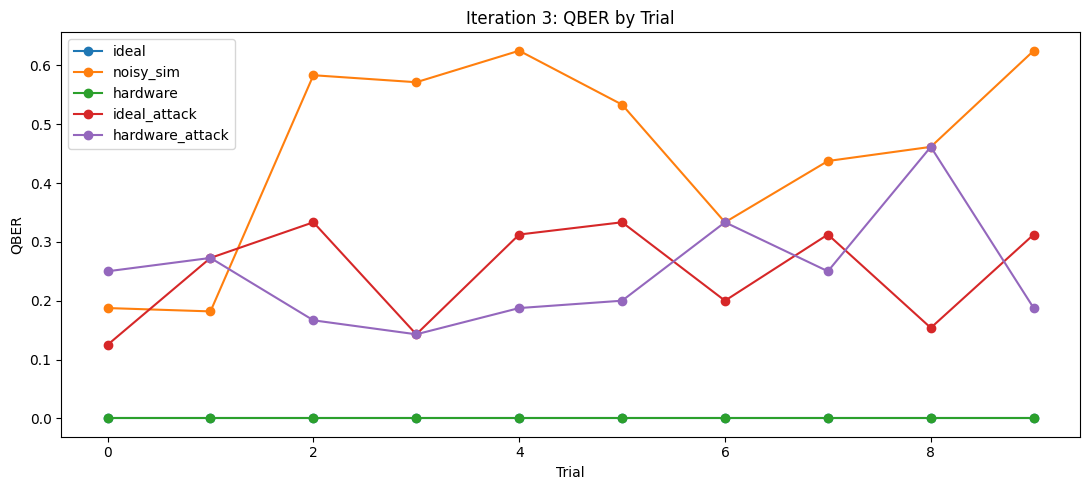

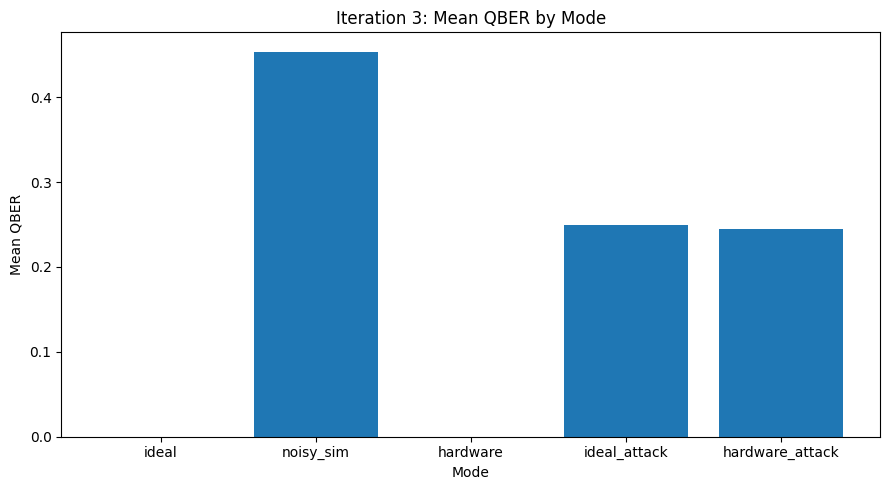

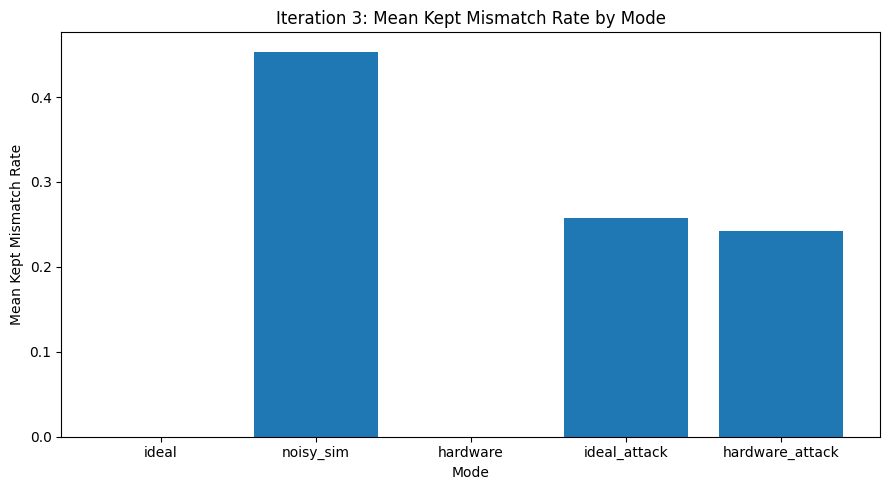

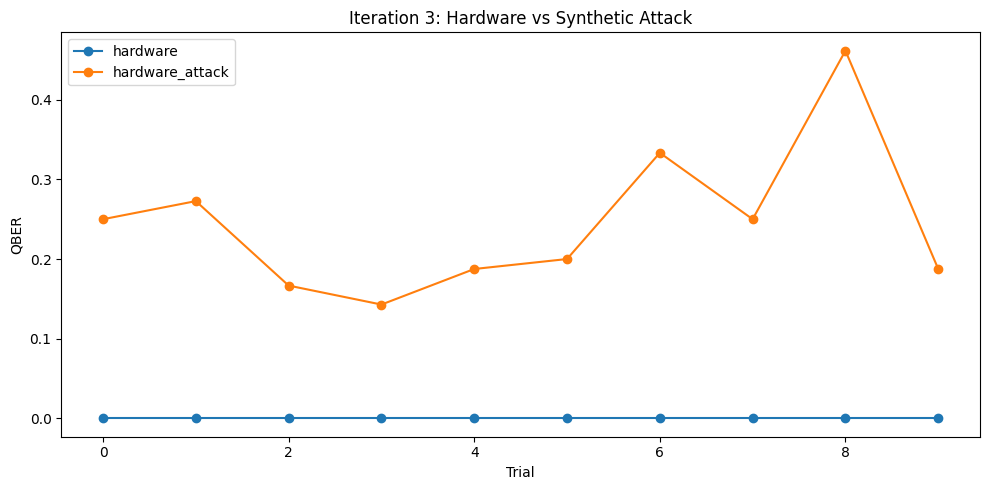


Summary:
{'ideal': {'num_trials': 10, 'mean_qber': 0.0, 'mean_retention_rate': 0.48666666666666664, 'mean_kept_mismatch_rate': 0.0, 'mean_sifted_key_length': 14.6, 'mean_attack_flip_count': 0.0, 'max_qber': 0.0, 'min_qber': 0.0}, 'noisy_sim': {'num_trials': 10, 'mean_qber': 0.45397852147852147, 'mean_retention_rate': 0.48666666666666664, 'mean_kept_mismatch_rate': 0.45361087441969794, 'mean_sifted_key_length': 14.6, 'mean_attack_flip_count': 0.0, 'max_qber': 0.625, 'min_qber': 0.18181818181818182}, 'hardware': {'num_trials': 10, 'mean_qber': 0.0, 'mean_retention_rate': 0.48666666666666664, 'mean_kept_mismatch_rate': 0.0, 'mean_sifted_key_length': 14.6, 'mean_attack_flip_count': 0.0, 'max_qber': 0.0, 'min_qber': 0.0}, 'ideal_attack': {'num_trials': 10, 'mean_qber': 0.2498597236097236, 'mean_retention_rate': 0.48666666666666664, 'mean_kept_mismatch_rate': 0.25794795890384126, 'mean_sifted_key_length': 14.6, 'mean_attack_flip_count': 3.8, 'max_qber': 0.3333333333333333, 'min_qber': 0.125

In [153]:
iteration_3_result = run_iteration_3_experiment(
    service=service,
    n_qubits=30,
    shots=4096,
    sample_size=16,
    num_trials=10,
    base_seed=42,
    backend_name="ibm_marrakesh",
    run_noisy_sim=True,
    run_hardware=True,
    run_ideal_attack=True,
    run_hardware_attack=True,
    hardware_attack_flip_probability=0.25,
    output_dir="outputs_iteration_3",
)

In [12]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler


Quantum_api_key = "0FSSQimyq-69tArkrSOOziitEXLrpq2muR4n6o_vU-3B"
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",   # or "ibm_cloud" on the new platform
    token=Quantum_api_key,
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/00ca2aed1b3548b49d7381ffbdd25394:d3eb3467-58b7-416f-85ed-a47b073286da::"
)

print(service.backends(simulator=False))


qiskit_runtime_service._discover_account:WARNING:2026-03-13 10:58:21,929: Loading account with the given token. A saved account will not be used.


[<IBMBackend('ibm_fez')>, <IBMBackend('ibm_torino')>, <IBMBackend('ibm_marrakesh')>]


In [13]:
"""
Iteration 4 BB84 experimental framework.

Research framing:
    Circuit-level experimental cryptographic evaluation under noise.
    This script does NOT claim production-ready QKD or deployment security.

Key improvements:
    - Hardware baseline and hardware-attack are paired from the same run.
    - SamplerV2 is used for IBM hardware execution.
    - Optional hardware suppression knobs: dynamical decoupling, gate twirling.
    - Threshold-based attack distinguishability statistics added.
    - Backend-derived noisy simulator retained only as a pessimistic stress-test arm.

Python:
    3.10+

Author:
    Research architecture draft for Muhammad's BB84 project.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass
from statistics import mean
from typing import Any, Iterable
import math
import random

import matplotlib.pyplot as plt
import numpy as np

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

try:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
except ImportError:  # pragma: no cover
    QiskitRuntimeService = None
    Sampler = None


# ---------------------------------------------------------------------
# Dataclasses
# ---------------------------------------------------------------------

@dataclass(frozen=True)
class ExperimentConfig:
    """Top-level experiment configuration."""

    n_qubits: int = 64
    shots: int = 4096
    trials: int = 10
    sample_fraction: float = 0.5
    synthetic_attack_flip_probability: float = 0.25
    seed: int = 1234
    optimization_level: int = 1
    enable_dynamical_decoupling: bool = False
    enable_gate_twirling: bool = False
    use_noisy_stress_test: bool = True
    min_hardware_qubits: int = 64
    threshold_grid: tuple[float, ...] = (
        0.01,
        0.02,
        0.03,
        0.05,
        0.08,
        0.10,
        0.12,
        0.15,
        0.20,
    )


@dataclass(frozen=True)
class TrialMetrics:
    """Per-trial structured metrics."""

    n_qubits: int
    shots: int
    seed: int
    backend_name: str
    disturbance_type: str
    raw_key_length: int
    sifted_key_length: int
    retention_rate: float
    sample_size: int
    errors_in_sample: int
    qber: float
    kept_mismatch_rate: float
    qber_ci_low: float
    qber_ci_high: float


@dataclass(frozen=True)
class AggregateMetrics:
    """Aggregate metrics for a mode."""

    mode: str
    mean_qber: float
    min_qber: float
    max_qber: float
    mean_kept_mismatch_rate: float
    mean_sifted_key_length: float
    mean_retention_rate: float
    strict_range_separation_reference_max: float | None = None
    strict_range_separation_target_min: float | None = None
    strict_range_separation: bool | None = None


@dataclass(frozen=True)
class BackendRunResult:
    """Container for raw execution output used by extraction."""

    counts: dict[str, int]
    backend_name: str


# ---------------------------------------------------------------------
# Utility functions
# ---------------------------------------------------------------------

def make_rng(seed: int) -> random.Random:
    """Create a seeded Python RNG."""
    return random.Random(seed)


def wilson_interval(errors: int, total: int, z: float = 1.96) -> tuple[float, float]:
    """Compute a 95% Wilson score interval for a binomial proportion."""
    if total == 0:
        return 0.0, 0.0
    p = errors / total
    denom = 1.0 + (z**2 / total)
    center = (p + z**2 / (2.0 * total)) / denom
    margin = (
        z
        * math.sqrt((p * (1.0 - p) / total) + (z**2 / (4.0 * total**2)))
        / denom
    )
    return max(0.0, center - margin), min(1.0, center + margin)


# ---------------------------------------------------------------------
# Required core functions
# ---------------------------------------------------------------------

def generate_bits_and_bases(
    n_qubits: int,
    rng: random.Random,
) -> tuple[list[int], list[int], list[int]]:
    """
    Generate Alice bits, Alice bases, and Bob bases.

    Basis encoding:
        0 -> Z basis
        1 -> X basis
    """
    alice_bits = [rng.randint(0, 1) for _ in range(n_qubits)]
    alice_bases = [rng.randint(0, 1) for _ in range(n_qubits)]
    bob_bases = [rng.randint(0, 1) for _ in range(n_qubits)]
    return alice_bits, alice_bases, bob_bases


def build_bb84_circuit(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
) -> QuantumCircuit:
    """
    Build a parallel BB84 circuit.

    For each qubit:
        - Alice prepares one of {|0>, |1>, |+>, |->}.
        - Bob measures in Z or X basis.
    """
    n_qubits = len(alice_bits)
    qreg = QuantumRegister(n_qubits, "q")
    creg = ClassicalRegister(n_qubits, "meas")
    circuit = QuantumCircuit(qreg, creg, name="bb84")

    for idx in range(n_qubits):
        # Alice preparation
        if alice_bases[idx] == 0:
            if alice_bits[idx] == 1:
                circuit.x(idx)
        else:
            if alice_bits[idx] == 1:
                circuit.x(idx)
            circuit.h(idx)

        # Bob measurement basis change
        if bob_bases[idx] == 1:
            circuit.h(idx)

    circuit.measure(qreg, creg)
    return circuit


def run_backend(
    circuit: QuantumCircuit,
    mode: str,
    shots: int,
    seed: int,
    backend: Any | None = None,
    service: Any | None = None,
    enable_dynamical_decoupling: bool = False,
    enable_gate_twirling: bool = False,
    optimization_level: int = 1,
) -> BackendRunResult:
    """
    Execute a circuit on one of:
        - ideal simulator
        - noisy simulator (stress-test only)
        - IBM hardware via SamplerV2

    Returns:
        BackendRunResult with counts and backend name.
    """
    if mode == "ideal":
        sim = AerSimulator(seed_simulator=seed)
        isa_circuit = transpile(
            circuit,
            backend=sim,
            optimization_level=optimization_level,
            seed_transpiler=seed,
        )
        job = sim.run(isa_circuit, shots=shots)
        counts = job.result().get_counts()
        return BackendRunResult(counts=counts, backend_name="aer_ideal")

    if mode == "noisy":
        if backend is None:
            raise ValueError("A hardware backend is required to derive a noise model.")
        noise_model = NoiseModel.from_backend(backend)
        noisy_sim = AerSimulator(
            noise_model=noise_model,
            seed_simulator=seed,
        )
        isa_circuit = transpile(
            circuit,
            backend=backend,
            optimization_level=optimization_level,
            seed_transpiler=seed,
        )
        job = noisy_sim.run(isa_circuit, shots=shots)
        counts = job.result().get_counts()
        return BackendRunResult(
            counts=counts,
            backend_name=f"noisy_from_{backend.name}",
        )

    if mode == "hardware":
        if Sampler is None or service is None or backend is None:
            raise ValueError(
                "Hardware mode requires qiskit-ibm-runtime, a service, and a backend."
            )

        isa_circuit = transpile(
            circuit,
            backend=backend,
            optimization_level=optimization_level,
            seed_transpiler=seed,
        )

        sampler = Sampler(mode=backend)
        sampler.options.default_shots = shots
        sampler.options.dynamical_decoupling.enable = enable_dynamical_decoupling
        sampler.options.twirling.enable_gates = enable_gate_twirling

        result = sampler.run([isa_circuit], shots=shots).result()
        counts = result[0].data.meas.get_counts()
        return BackendRunResult(counts=counts, backend_name=backend.name)

    raise ValueError(f"Unsupported mode: {mode}")


def extract_bob_bits(
    counts: dict[str, int],
    n_qubits: int,
) -> list[int]:
    """
    Extract Bob's effective raw key by majority vote per qubit position.

    This matches the current research framing:
        repeated shots are used to suppress stochastic fluctuations and
        produce a single effective bit per qubit position.
    """
    total_ones = [0] * n_qubits
    total_shots = 0

    for bitstring, freq in counts.items():
        canonical = bitstring.replace(" ", "")
        # Reverse so index 0 corresponds to qubit 0
        bits = canonical[::-1]
        if len(bits) != n_qubits:
            raise ValueError(
                f"Unexpected bitstring length {len(bits)} for n_qubits={n_qubits}."
            )
        total_shots += freq
        for idx, bit_char in enumerate(bits):
            total_ones[idx] += int(bit_char) * freq

    if total_shots == 0:
        raise ValueError("No shots found in counts.")

    bob_bits = [
        1 if total_ones[idx] >= (total_shots / 2.0) else 0
        for idx in range(n_qubits)
    ]
    return bob_bits


def sift_keys(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bits: list[int],
    bob_bases: list[int],
) -> tuple[list[int], list[int]]:
    """Keep positions where Alice and Bob used the same basis."""
    sifted_alice: list[int] = []
    sifted_bob: list[int] = []

    for a_bit, a_basis, b_bit, b_basis in zip(
        alice_bits, alice_bases, bob_bits, bob_bases
    ):
        if a_basis == b_basis:
            sifted_alice.append(a_bit)
            sifted_bob.append(b_bit)

    return sifted_alice, sifted_bob


def estimate_qber(
    sifted_alice: list[int],
    sifted_bob: list[int],
    sample_fraction: float,
    rng: random.Random,
) -> tuple[float, int, int, float, tuple[float, float]]:
    """
    Estimate QBER by sampling a subset of sifted bits.

    Returns:
        qber,
        sample_size,
        errors_in_sample,
        kept_mismatch_rate,
        (ci_low, ci_high)
    """
    if len(sifted_alice) != len(sifted_bob):
        raise ValueError("Sifted keys must have equal length.")

    sifted_len = len(sifted_alice)
    if sifted_len == 0:
        return 0.0, 0, 0, 0.0, (0.0, 0.0)

    kept_errors = sum(
        int(a != b) for a, b in zip(sifted_alice, sifted_bob)
    )
    kept_mismatch_rate = kept_errors / sifted_len

    sample_size = max(1, int(round(sample_fraction * sifted_len)))
    sample_indices = rng.sample(range(sifted_len), k=min(sample_size, sifted_len))
    sample_errors = sum(
        int(sifted_alice[idx] != sifted_bob[idx]) for idx in sample_indices
    )
    qber = sample_errors / len(sample_indices)
    ci_low, ci_high = wilson_interval(sample_errors, len(sample_indices))
    return qber, len(sample_indices), sample_errors, kept_mismatch_rate, (ci_low, ci_high)


def simulate_intercept_resend(
    alice_bits: list[int],
    alice_bases: list[int],
    bob_bases: list[int],
    rng: random.Random,
) -> list[int]:
    """
    Simulate full intercept-resend attack classically.

    Eve:
        - chooses a random basis for each qubit,
        - measures in that basis,
        - resends the measured state to Bob.

    For full intercept-resend on BB84, sifted-key QBER approaches ~25%.
    """
    eve_bases = [rng.randint(0, 1) for _ in range(len(alice_bits))]
    eve_bits: list[int] = []

    for a_bit, a_basis, e_basis in zip(alice_bits, alice_bases, eve_bases):
        if a_basis == e_basis:
            eve_bits.append(a_bit)
        else:
            eve_bits.append(rng.randint(0, 1))

    bob_bits: list[int] = []
    for e_bit, e_basis, b_basis in zip(eve_bits, eve_bases, bob_bases):
        if e_basis == b_basis:
            bob_bits.append(e_bit)
        else:
            bob_bits.append(rng.randint(0, 1))

    return bob_bits


def apply_synthetic_attack(
    sifted_bob: list[int],
    flip_probability: float,
    rng: random.Random,
) -> list[int]:
    """
    Apply post-measurement synthetic adversarial disturbance.

    This is used for the hardware-attack mode so that the same baseline
    hardware run can be reused without requiring mid-circuit interception.
    """
    attacked = []
    for bit in sifted_bob:
        if rng.random() < flip_probability:
            attacked.append(1 - bit)
        else:
            attacked.append(bit)
    return attacked


def summarize_metrics(
    mode: str,
    trial_metrics: list[TrialMetrics],
    reference_metrics: list[TrialMetrics] | None = None,
) -> AggregateMetrics:
    """Aggregate trial metrics for one experimental mode."""
    qbers = [m.qber for m in trial_metrics]
    mismatches = [m.kept_mismatch_rate for m in trial_metrics]
    sifted_lengths = [m.sifted_key_length for m in trial_metrics]
    retention_rates = [m.retention_rate for m in trial_metrics]

    strict_range_separation = None
    reference_max = None
    target_min = None

    if reference_metrics:
        reference_qbers = [m.qber for m in reference_metrics]
        reference_max = max(reference_qbers)
        target_min = min(qbers)
        strict_range_separation = target_min > reference_max

    return AggregateMetrics(
        mode=mode,
        mean_qber=mean(qbers) if qbers else 0.0,
        min_qber=min(qbers) if qbers else 0.0,
        max_qber=max(qbers) if qbers else 0.0,
        mean_kept_mismatch_rate=mean(mismatches) if mismatches else 0.0,
        mean_sifted_key_length=mean(sifted_lengths) if sifted_lengths else 0.0,
        mean_retention_rate=mean(retention_rates) if retention_rates else 0.0,
        strict_range_separation_reference_max=reference_max,
        strict_range_separation_target_min=target_min,
        strict_range_separation=strict_range_separation,
    )


def run_sanity_checks(summary: dict[str, AggregateMetrics]) -> None:
    """
    Run mandatory scientific sanity checks.

    Verifies:
        - ideal QBER ≈ 0
        - attack QBER significantly higher
        - retention ≈ 50%
    """
    ideal_qber = summary["ideal"].mean_qber
    ideal_attack_qber = summary["ideal_attack"].mean_qber
    ideal_retention = summary["ideal"].mean_retention_rate

    if ideal_qber > 0.05:
        raise AssertionError(f"Ideal QBER too high: {ideal_qber:.4f}")

    if ideal_attack_qber < 0.15:
        raise AssertionError(
            f"Ideal attack QBER too low to indicate attack behavior: {ideal_attack_qber:.4f}"
        )

    if not (0.35 <= ideal_retention <= 0.65):
        raise AssertionError(
            f"Sifting retention deviates too strongly from 50% expectation: {ideal_retention:.4f}"
        )


# ---------------------------------------------------------------------
# Backend and experiment helpers
# ---------------------------------------------------------------------

def select_hardware_backend(
    service: Any,
    min_num_qubits: int,
) -> Any:
    """
    Select a non-simulator operational backend with enough qubits.

    This intentionally avoids pinning a backend name.
    """
    backends = service.backends(
        simulator=False,
        operational=True,
        min_num_qubits=min_num_qubits,
    )
    if not backends:
        raise RuntimeError(
            f"No operational non-simulator backends with >= {min_num_qubits} qubits."
        )

    def sort_key(b: Any) -> tuple[float, int, str]:
        pending_jobs = getattr(getattr(b, "status", lambda: None)(), "pending_jobs", 10**9)
        n_qubits = getattr(b, "num_qubits", 0)
        return (pending_jobs, -n_qubits, b.name)

    return sorted(backends, key=sort_key)[0]


def build_trial_metrics(
    *,
    config: ExperimentConfig,
    seed: int,
    backend_name: str,
    disturbance_type: str,
    raw_key_length: int,
    sifted_alice: list[int],
    sifted_bob: list[int],
    qber: float,
    sample_size: int,
    errors_in_sample: int,
    kept_mismatch_rate: float,
    qber_interval: tuple[float, float],
) -> TrialMetrics:
    """Create a TrialMetrics object."""
    return TrialMetrics(
        n_qubits=config.n_qubits,
        shots=config.shots,
        seed=seed,
        backend_name=backend_name,
        disturbance_type=disturbance_type,
        raw_key_length=raw_key_length,
        sifted_key_length=len(sifted_alice),
        retention_rate=(len(sifted_alice) / raw_key_length) if raw_key_length else 0.0,
        sample_size=sample_size,
        errors_in_sample=errors_in_sample,
        qber=qber,
        kept_mismatch_rate=kept_mismatch_rate,
        qber_ci_low=qber_interval[0],
        qber_ci_high=qber_interval[1],
    )


def run_single_baseline_trial(
    *,
    config: ExperimentConfig,
    mode: str,
    trial_seed: int,
    backend: Any | None = None,
    service: Any | None = None,
) -> tuple[TrialMetrics, dict[str, Any]]:
    """
    Run one baseline trial and return both metrics and cached raw data.

    Cached raw data are reused for paired attack analysis.
    """
    rng = make_rng(trial_seed)
    alice_bits, alice_bases, bob_bases = generate_bits_and_bases(config.n_qubits, rng)

    if mode in {"ideal", "noisy", "hardware"}:
        circuit = build_bb84_circuit(alice_bits, alice_bases, bob_bases)
        backend_result = run_backend(
            circuit=circuit,
            mode=mode,
            shots=config.shots,
            seed=trial_seed,
            backend=backend,
            service=service,
            enable_dynamical_decoupling=config.enable_dynamical_decoupling,
            enable_gate_twirling=config.enable_gate_twirling,
            optimization_level=config.optimization_level,
        )
        bob_bits = extract_bob_bits(backend_result.counts, config.n_qubits)
        backend_name = backend_result.backend_name
    else:
        raise ValueError(f"Unsupported baseline mode: {mode}")

    sifted_alice, sifted_bob = sift_keys(
        alice_bits, alice_bases, bob_bits, bob_bases
    )
    qber, sample_size, sample_errors, kept_mismatch_rate, qber_interval = estimate_qber(
        sifted_alice=sifted_alice,
        sifted_bob=sifted_bob,
        sample_fraction=config.sample_fraction,
        rng=rng,
    )

    metrics = build_trial_metrics(
        config=config,
        seed=trial_seed,
        backend_name=backend_name,
        disturbance_type=mode,
        raw_key_length=config.n_qubits,
        sifted_alice=sifted_alice,
        sifted_bob=sifted_bob,
        qber=qber,
        sample_size=sample_size,
        errors_in_sample=sample_errors,
        kept_mismatch_rate=kept_mismatch_rate,
        qber_interval=qber_interval,
    )

    cache = {
        "alice_bits": alice_bits,
        "alice_bases": alice_bases,
        "bob_bases": bob_bases,
        "bob_bits": bob_bits,
        "sifted_alice": sifted_alice,
        "sifted_bob": sifted_bob,
        "backend_name": backend_name,
    }
    return metrics, cache


def run_single_attack_trial_from_cache(
    *,
    config: ExperimentConfig,
    trial_seed: int,
    attack_mode: str,
    cache: dict[str, Any],
) -> TrialMetrics:
    """Run an attack trial from cached baseline data."""
    rng = make_rng(trial_seed + 10_000)

    if attack_mode == "ideal_attack":
        bob_bits = simulate_intercept_resend(
            alice_bits=cache["alice_bits"],
            alice_bases=cache["alice_bases"],
            bob_bases=cache["bob_bases"],
            rng=rng,
        )
        sifted_alice, sifted_bob = sift_keys(
            cache["alice_bits"],
            cache["alice_bases"],
            bob_bits,
            cache["bob_bases"],
        )
        backend_name = "ideal_intercept_resend"
    elif attack_mode == "hardware_attack":
        sifted_alice = list(cache["sifted_alice"])
        sifted_bob = apply_synthetic_attack(
            sifted_bob=list(cache["sifted_bob"]),
            flip_probability=config.synthetic_attack_flip_probability,
            rng=rng,
        )
        backend_name = cache["backend_name"]
    else:
        raise ValueError(f"Unsupported attack mode: {attack_mode}")

    qber, sample_size, sample_errors, kept_mismatch_rate, qber_interval = estimate_qber(
        sifted_alice=sifted_alice,
        sifted_bob=sifted_bob,
        sample_fraction=config.sample_fraction,
        rng=rng,
    )

    return build_trial_metrics(
        config=config,
        seed=trial_seed,
        backend_name=backend_name,
        disturbance_type=attack_mode,
        raw_key_length=config.n_qubits,
        sifted_alice=sifted_alice,
        sifted_bob=sifted_bob,
        qber=qber,
        sample_size=sample_size,
        errors_in_sample=sample_errors,
        kept_mismatch_rate=kept_mismatch_rate,
        qber_interval=qber_interval,
    )


def compute_threshold_detection_stats(
    baseline_trials: list[TrialMetrics],
    attack_trials: list[TrialMetrics],
    thresholds: Iterable[float],
) -> list[dict[str, float]]:
    """
    Compute threshold-based distinguishability statistics.

    Detection rule:
        predict "attack" if QBER >= threshold
    """
    output: list[dict[str, float]] = []

    baseline_qbers = [m.qber for m in baseline_trials]
    attack_qbers = [m.qber for m in attack_trials]

    for threshold in thresholds:
        false_positive_rate = (
            sum(q >= threshold for q in baseline_qbers) / len(baseline_qbers)
            if baseline_qbers
            else 0.0
        )
        true_positive_rate = (
            sum(q >= threshold for q in attack_qbers) / len(attack_qbers)
            if attack_qbers
            else 0.0
        )
        output.append(
            {
                "threshold": float(threshold),
                "false_positive_rate": false_positive_rate,
                "true_positive_rate": true_positive_rate,
            }
        )
    return output


def plot_qber_boxplot(results: dict[str, list[TrialMetrics]]) -> None:
    """Plot one figure showing QBER distributions by mode."""
    order = [
        "ideal",
        "noisy",
        "hardware",
        "ideal_attack",
        "hardware_attack",
    ]
    labels = [mode for mode in order if mode in results]
    data = [[m.qber for m in results[mode]] for mode in labels]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(data, tick_labels=labels, showmeans=True)
    ax.set_xlabel("Mode")
    ax.set_ylabel("QBER")
    ax.set_title("BB84 QBER by experimental mode")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_threshold_sweep(threshold_rows: list[dict[str, float]]) -> None:
    """Plot detection performance versus QBER threshold."""
    thresholds = [row["threshold"] for row in threshold_rows]
    fpr = [row["false_positive_rate"] for row in threshold_rows]
    tpr = [row["true_positive_rate"] for row in threshold_rows]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(thresholds, fpr, marker="o", label="False positive rate")
    ax.plot(thresholds, tpr, marker="s", label="True positive rate")
    ax.set_xlabel("QBER threshold")
    ax.set_ylabel("Rate")
    ax.set_title("Threshold-based attack detection")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def run_experiment(config: ExperimentConfig) -> dict[str, Any]:
    """
    Run the full Iteration 4 experiment.

    Modes:
        - ideal
        - noisy (optional pessimistic stress-test)
        - hardware
        - ideal_attack
        - hardware_attack
    """
    service = None
    hardware_backend = None

    if QiskitRuntimeService is not None:
        service = QiskitRuntimeService()
        hardware_backend = select_hardware_backend(
            service=service,
            min_num_qubits=config.min_hardware_qubits,
        )

    trial_results: dict[str, list[TrialMetrics]] = {
        "ideal": [],
        "hardware": [],
        "ideal_attack": [],
        "hardware_attack": [],
    }
    if config.use_noisy_stress_test:
        trial_results["noisy"] = []

    for trial_index in range(config.trials):
        trial_seed = config.seed + trial_index

        # Ideal baseline
        ideal_metrics, ideal_cache = run_single_baseline_trial(
            config=config,
            mode="ideal",
            trial_seed=trial_seed,
        )
        trial_results["ideal"].append(ideal_metrics)

        # Ideal attack from identical Alice/Bob settings
        ideal_attack_metrics = run_single_attack_trial_from_cache(
            config=config,
            trial_seed=trial_seed,
            attack_mode="ideal_attack",
            cache=ideal_cache,
        )
        trial_results["ideal_attack"].append(ideal_attack_metrics)

        # Hardware baseline + paired hardware attack
        if hardware_backend is not None and service is not None:
            hardware_metrics, hardware_cache = run_single_baseline_trial(
                config=config,
                mode="hardware",
                trial_seed=trial_seed,
                backend=hardware_backend,
                service=service,
            )
            trial_results["hardware"].append(hardware_metrics)

            hardware_attack_metrics = run_single_attack_trial_from_cache(
                config=config,
                trial_seed=trial_seed,
                attack_mode="hardware_attack",
                cache=hardware_cache,
            )
            trial_results["hardware_attack"].append(hardware_attack_metrics)

            if config.use_noisy_stress_test:
                noisy_metrics, _ = run_single_baseline_trial(
                    config=config,
                    mode="noisy",
                    trial_seed=trial_seed,
                    backend=hardware_backend,
                )
                trial_results["noisy"].append(noisy_metrics)

    summary: dict[str, AggregateMetrics] = {}
    for mode, metrics in trial_results.items():
        if not metrics:
            continue
        reference = None
        if mode == "hardware_attack" and trial_results.get("hardware"):
            reference = trial_results["hardware"]
        summary[mode] = summarize_metrics(mode, metrics, reference)

    run_sanity_checks(summary)

    threshold_rows: list[dict[str, float]] = []
    if trial_results.get("hardware") and trial_results.get("hardware_attack"):
        threshold_rows = compute_threshold_detection_stats(
            baseline_trials=trial_results["hardware"],
            attack_trials=trial_results["hardware_attack"],
            thresholds=config.threshold_grid,
        )

    return {
        "config": asdict(config),
        "hardware_backend_name": getattr(hardware_backend, "name", None),
        "trial_results": {
            mode: [asdict(metric) for metric in metrics]
            for mode, metrics in trial_results.items()
        },
        "summary": {
            mode: asdict(aggregate)
            for mode, aggregate in summary.items()
        },
        "threshold_detection": threshold_rows,
    }


def main() -> None:
    """Entry point."""
    config = ExperimentConfig(
        n_qubits=64,
        shots=4096,
        trials=10,
        sample_fraction=0.5,
        synthetic_attack_flip_probability=0.25,
        seed=1234,
        optimization_level=1,
        enable_dynamical_decoupling=True,
        enable_gate_twirling=True,
        use_noisy_stress_test=True,
        min_hardware_qubits=64,
    )

    results = run_experiment(config)

    print("\n=== SUMMARY ===")
    for mode, aggregate in results["summary"].items():
        print(f"\nMode: {mode}")
        for key, value in aggregate.items():
            print(f"  {key}: {value}")

    print("\n=== THRESHOLD DETECTION ===")
    for row in results["threshold_detection"]:
        print(row)

    # Plot only if results exist
    deserialized_trials = {
        mode: [TrialMetrics(**row) for row in rows]
        for mode, rows in results["trial_results"].items()
    }
    plot_qber_boxplot(deserialized_trials)
    if results["threshold_detection"]:
        plot_threshold_sweep(results["threshold_detection"])


if __name__ == "__main__":
    main()

InvalidAccountError: 'Unable to retrieve instances. Please check that you are using a valid API token.'